In [2]:
import pandas as pd
import numpy as np
import tensorflow as tf

from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dropout, Dense
from tensorflow.keras.layers import LSTM, Bidirectional, Dropout, Dense

In [3]:
df = pd.read_csv("combined_dataset_latest.csv")

In [4]:
# Normalize
df["label"] = df["label"].astype(str).str.strip().str.lower()
df["url"] = df["url"].astype(str).str.strip()  
df["screenshot_path"] = df["screenshot_path"].astype(str).str.strip()

In [5]:
# First split: train (70%) + temp (30%)
df_train, df_temp = train_test_split(
    df,
    test_size=0.30,
    random_state=42,
    stratify=df["label"]
)

# Second split: val (15%) + test (15%)
df_val, df_test = train_test_split(
    df_temp,
    test_size=0.50,
    random_state=42,
    stratify=df_temp["label"]
)

print("Rows:", len(df_train), len(df_val), len(df_test))

Rows: 13748 2946 2947


In [6]:
y_train = (df_train["label"] == "phish").astype(int).values
y_val   = (df_val["label"] == "phish").astype(int).values
y_test  = (df_test["label"] == "phish").astype(int).values

In [7]:
tokenizer = Tokenizer(char_level=True, lower=False, oov_token="<OOV>")
tokenizer.fit_on_texts(df_train["url"])

vocab_size = len(tokenizer.word_index) + 1
print("vocab_size:", vocab_size)

vocab_size: 214


In [8]:
# Convert to sequences
X_train_url = tokenizer.texts_to_sequences(df_train["url"])
X_val_url   = tokenizer.texts_to_sequences(df_val["url"])
X_test_url  = tokenizer.texts_to_sequences(df_test["url"])

In [9]:
df_train['url_len'] = df_train['url'].astype(str).str.len()

print(df_train['url_len'].describe())
print(df_train['url_len'].quantile([0.9, 0.95, 0.99]))

count    13748.000000
mean        55.786078
std         75.748614
min         12.000000
25%         23.000000
50%         36.000000
75%         68.000000
max       4243.000000
Name: url_len, dtype: float64
0.90    113.0
0.95    157.0
0.99    245.0
Name: url_len, dtype: float64


In [10]:
# Padding
MAX_LEN = 256
X_train_url = pad_sequences(X_train_url, maxlen=MAX_LEN, padding="post", truncating="post")
X_val_url   = pad_sequences(X_val_url,   maxlen=MAX_LEN, padding="post", truncating="post")
X_test_url  = pad_sequences(X_test_url,  maxlen=MAX_LEN, padding="post", truncating="post")

In [11]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.utils import load_img, img_to_array
from tensorflow.keras.applications.densenet import preprocess_input

IMG_SIZE = (224, 224)

def load_images(paths, img_size=IMG_SIZE):
    images = []

    for p in paths:
        img = load_img(p, target_size=img_size)  # PIL image
        img = img_to_array(img)                   # (H, W, 3)
        img = preprocess_input(img)               # DenseNet preprocess
        images.append(img)

    return np.array(images)

In [12]:
X_train_img = load_images(df_train["screenshot_path"])
X_val_img   = load_images(df_val["screenshot_path"])
X_test_img  = load_images(df_test["screenshot_path"])

In [13]:
print("URL shapes:", X_train_url.shape, X_val_url.shape, X_test_url.shape)
print("IMG shapes:", X_train_img.shape, X_val_img.shape, X_test_img.shape)
print("Y shapes  :", y_train.shape, y_val.shape, y_test.shape)

assert len(X_train_url) == len(X_train_img) == len(y_train)
assert len(X_val_url) == len(X_val_img) == len(y_val)
assert len(X_test_url) == len(X_test_img) == len(y_test)

URL shapes: (13748, 256) (2946, 256) (2947, 256)
IMG shapes: (13748, 224, 224, 3) (2946, 224, 224, 3) (2947, 224, 224, 3)
Y shapes  : (13748,) (2946,) (2947,)


### **BiGRU**

In [24]:
import keras_tuner as kt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, GRU, Dense, Dropout, Bidirectional
from tensorflow.keras.optimizers import Adam

def build_bigru_model(hp):
    lr = hp.Float("lr", min_value=1e-4, max_value=1e-2, sampling="log")

    model = Sequential([
        Embedding(vocab_size, 64, input_length=MAX_LEN, mask_zero=True),
        Bidirectional(GRU(64, dropout=0.2)),
        Dense(64, activation="relu", name="url_feat"),
        Dropout(0.5),
        Dense(1, activation="sigmoid")
    ])

    model.compile(
        optimizer=Adam(learning_rate=lr),
        loss="binary_crossentropy",
        metrics=[
            "accuracy",
            tf.keras.metrics.Precision(name="precision"),
            tf.keras.metrics.Recall(name="recall")
        ]
    )
    return model

In [25]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

In [26]:
tuner = kt.RandomSearch(
    hypermodel=build_bigru_model,
    objective=kt.Objective("val_accuracy", direction="max"),  
    max_trials=10,
    executions_per_trial=1,
    directory="kt_runs",
    project_name="url_bigru_randomsearch",
    overwrite=True,
    seed=42
)

In [27]:
tuner.search(
    X_train_url, y_train,
    validation_data=(X_val_url, y_val),
    epochs=50,
    batch_size=tuner.oracle.hyperparameters.Choice(
        "batch_size", [16, 32, 64]
    ),
    callbacks=[early_stop],
    verbose=1
)

Trial 10 Complete [00h 27m 16s]
val_accuracy: 0.9562118053436279

Best val_accuracy So Far: 0.9670739769935608
Total elapsed time: 02h 49m 34s


In [29]:
best_hp = tuner.get_best_hyperparameters(num_trials=1)[0]
print("Best hyperparameters:")
print("  lr:", best_hp.get("lr"))
print("  batch_size:", best_hp.get("batch_size"))

best_model = tuner.get_best_models(num_models=1)[0]

Best hyperparameters:
  lr: 0.0019004375238737127
  batch_size: 16


In [137]:
# 1) Get best hyperparameters
best_hp = tuner.get_best_hyperparameters(1)[0]

# 2) Rebuild from scratch using the best hyperparameters
fresh_model = build_bigru_model(best_hp)   

# 3) Train from scratch (this history is what you plot)
history = fresh_model.fit(
    X_train_url, y_train,
    validation_data=(X_val_url, y_val),
    epochs=50,  # max
    batch_size=best_hp.get("batch_size"),
    callbacks=[early_stop],
    verbose=1
)

# 4) Save + test
fresh_model.save("url_bigru_patience.keras")
results = fresh_model.evaluate(X_test_url, y_test, verbose=0, return_dict=True)
print(results)

Epoch 1/50
860/860 ━━━━━━━━━━━━━━━━━━━━ 107s 120ms/step - accuracy: 0.9039 - loss: 0.2573 - precision: 0.9006 - recall: 0.9002 - val_accuracy: 0.9362 - val_loss: 0.1778 - val_precision: 0.9124 - val_recall: 0.9599
Epoch 2/50
860/860 ━━━━━━━━━━━━━━━━━━━━ 107s 124ms/step - accuracy: 0.9467 - loss: 0.1499 - precision: 0.9446 - recall: 0.9450 - val_accuracy: 0.9532 - val_loss: 0.1305 - val_precision: 0.9477 - val_recall: 0.9557
Epoch 3/50
860/860 ━━━━━━━━━━━━━━━━━━━━ 103s 119ms/step - accuracy: 0.9554 - loss: 0.1244 - precision: 0.9561 - recall: 0.9513 - val_accuracy: 0.9538 - val_loss: 0.1235 - val_precision: 0.9522 - val_recall: 0.9522
Epoch 4/50
860/860 ━━━━━━━━━━━━━━━━━━━━ 104s 121ms/step - accuracy: 0.9614 - loss: 0.1067 - precision: 0.9609 - recall: 0.9590 - val_accuracy: 0.9586 - val_loss: 0.1213 - val_precision: 0.9520 - val_recall: 0.9627
Epoch 5/50
860/860 ━━━━━━━━━━━━━━━━━━━━ 103s 119ms/step - accuracy: 0.9674 - loss: 0.0900 - precision: 0.9682 - recall: 0.9641 - val_accuracy: 0

In [138]:
fresh_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ (None, 256, 64)        │        13,696 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_6 (Bidirectional) │ (None, 128)            │        49,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ url_feat (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 215,813 (843.02 KB)

 Trainable params: 71,937 (281.00 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 143,876 (562.02 KB)

#### **Plot graph**

In [139]:
import numpy as np

precision = np.array(history.history["precision"])
recall = np.array(history.history["recall"])
val_precision = np.array(history.history["val_precision"])
val_recall = np.array(history.history["val_recall"])

f1 = 2 * (precision * recall) / (precision + recall + 1e-8)
val_f1 = 2 * (val_precision * val_recall) / (val_precision + val_recall + 1e-8)

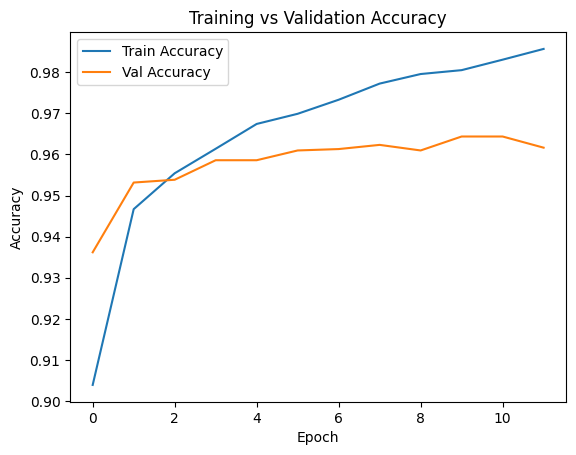

In [140]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Val Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.show()

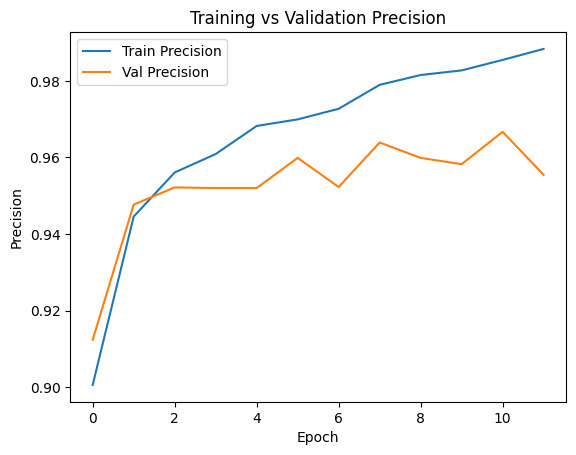

In [141]:
plt.figure()
plt.plot(history.history["precision"], label="Train Precision")
plt.plot(history.history["val_precision"], label="Val Precision")
plt.xlabel("Epoch")
plt.ylabel("Precision")
plt.title("Training vs Validation Precision")
plt.legend()
plt.show()

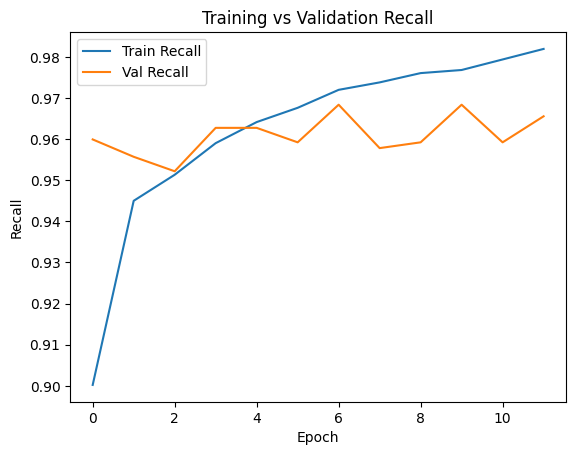

In [142]:
plt.figure()
plt.plot(history.history["recall"], label="Train Recall")
plt.plot(history.history["val_recall"], label="Val Recall")
plt.xlabel("Epoch")
plt.ylabel("Recall")
plt.title("Training vs Validation Recall")
plt.legend()
plt.show()

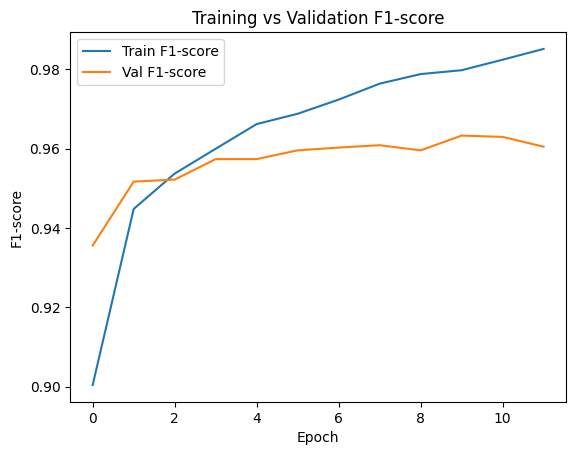

In [143]:
plt.figure()
plt.plot(f1, label="Train F1-score")
plt.plot(val_f1, label="Val F1-score")
plt.xlabel("Epoch")
plt.ylabel("F1-score")
plt.title("Training vs Validation F1-score")
plt.legend()
plt.show()

### **BiLSTM**

In [41]:
import keras_tuner as kt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Bidirectional
from tensorflow.keras.optimizers import Adam

# -------------------------
#  Build model for tuner
# -------------------------
def build_bilstm_model(hp):
    lr = hp.Float("lr", min_value=1e-4, max_value=1e-2, sampling="log")

    embedding_dim = 32

    model = Sequential()

    model.add(Embedding(
        input_dim=vocab_size,
        output_dim=embedding_dim,
        input_length=MAX_LEN,
        mask_zero=True
    ))

    model.add(Bidirectional(LSTM(
        64,
        return_sequences=True,
        activation="tanh",
        dropout=0.2
    )))

    model.add(Bidirectional(LSTM(
        32,
        activation="tanh",
        dropout=0.2
    )))

    model.add(Dense(64, activation="relu", name="url_feat"))
    model.add(Dropout(0.5))

    model.add(Dense(1, activation="sigmoid"))

    model.compile(
        optimizer=Adam(learning_rate=lr),
        loss="binary_crossentropy",
        metrics=[
            "accuracy",
            tf.keras.metrics.Precision(name="precision"),
            tf.keras.metrics.Recall(name="recall")
        ]   
    )
    return model

In [42]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

In [43]:
tuner = kt.RandomSearch(
    hypermodel=build_bilstm_model,
    objective=kt.Objective("val_accuracy", direction="max"),  # or val_loss min
    max_trials=10,
    executions_per_trial=1,
    directory="kt_runs",
    project_name="url_bilstm_randomsearch",
    overwrite=True,
    seed=42
)

In [44]:
tuner.search(
    X_train_url, y_train,
    validation_data=(X_val_url, y_val),
    epochs=50,  # max; early stopping decides actual epoch
    batch_size=tuner.oracle.hyperparameters.Choice("batch_size", [16, 32, 64]),
    callbacks=[early_stop],   
    verbose=1
)

Trial 10 Complete [00h 52m 36s]
val_accuracy: 0.9599456787109375

Best val_accuracy So Far: 0.9663951396942139
Total elapsed time: 06h 10m 16s


In [46]:
best_hp = tuner.get_best_hyperparameters(num_trials=1)[0]
print("Best hyperparameters:")
print("  lr:", best_hp.get("lr"))
print("  batch_size:", best_hp.get("batch_size"))

best_model = tuner.get_best_models(num_models=1)[0]

Best hyperparameters:
  lr: 0.0019004375238737127
  batch_size: 16


In [130]:
# 1) Get best hyperparameters
best_hp = tuner.get_best_hyperparameters(1)[0]

# 2) Rebuild from scratch using the best hyperparameters
fresh_model = build_bilstm_model(best_hp)   

# 3) Train from scratch (this history is what you plot)
history = fresh_model.fit(
    X_train_url, y_train,
    validation_data=(X_val_url, y_val),
    epochs=50,  # max
    batch_size=best_hp.get("batch_size"),
    callbacks=[early_stop],
    verbose=1
)

# 4) Save + test
fresh_model.save("url_bilstm_patience.keras")
results = fresh_model.evaluate(X_test_url, y_test, verbose=0, return_dict=True)
print(results)

Epoch 1/50
860/860 ━━━━━━━━━━━━━━━━━━━━ 183s 209ms/step - accuracy: 0.8934 - loss: 0.2679 - precision: 0.8842 - recall: 0.8965 - val_accuracy: 0.9308 - val_loss: 0.1879 - val_precision: 0.9012 - val_recall: 0.9620
Epoch 2/50
860/860 ━━━━━━━━━━━━━━━━━━━━ 189s 220ms/step - accuracy: 0.9310 - loss: 0.1895 - precision: 0.9272 - recall: 0.9302 - val_accuracy: 0.9362 - val_loss: 0.1841 - val_precision: 0.9401 - val_recall: 0.9269
Epoch 3/50
860/860 ━━━━━━━━━━━━━━━━━━━━ 186s 216ms/step - accuracy: 0.9390 - loss: 0.1648 - precision: 0.9363 - recall: 0.9375 - val_accuracy: 0.9481 - val_loss: 0.1412 - val_precision: 0.9561 - val_recall: 0.9353
Epoch 4/50
860/860 ━━━━━━━━━━━━━━━━━━━━ 189s 220ms/step - accuracy: 0.9478 - loss: 0.1405 - precision: 0.9464 - recall: 0.9453 - val_accuracy: 0.9518 - val_loss: 0.1396 - val_precision: 0.9444 - val_recall: 0.9564
Epoch 5/50
860/860 ━━━━━━━━━━━━━━━━━━━━ 187s 218ms/step - accuracy: 0.9529 - loss: 0.1298 - precision: 0.9510 - recall: 0.9515 - val_accuracy: 0

In [49]:
fresh_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 256, 32)        │         6,848 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_2 (Bidirectional) │ (None, 256, 128)       │        49,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_3 (Bidirectional) │ (None, 64)             │        41,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ url_feat (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 305,861 (1.17 MB)

 Trainable params: 101,953 (398.25 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 203,908 (796.52 KB)

#### **Plot Graph**

In [132]:
import numpy as np

precision = np.array(history.history["precision"])
recall = np.array(history.history["recall"])
val_precision = np.array(history.history["val_precision"])
val_recall = np.array(history.history["val_recall"])

f1 = 2 * (precision * recall) / (precision + recall + 1e-8)
val_f1 = 2 * (val_precision * val_recall) / (val_precision + val_recall + 1e-8)

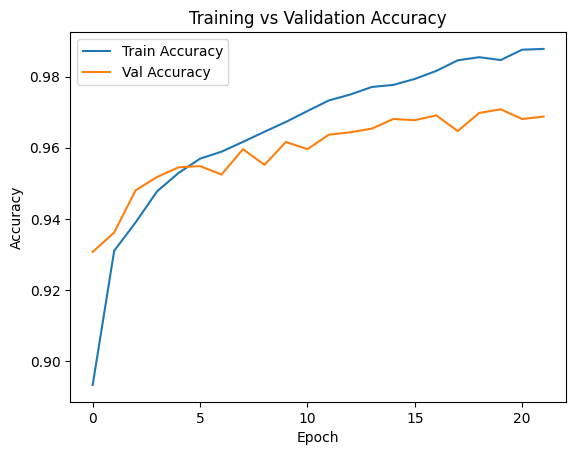

In [133]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Val Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.show()

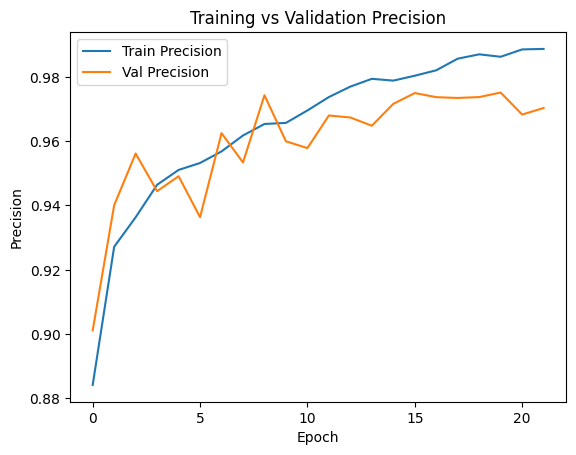

In [134]:
plt.figure()
plt.plot(history.history["precision"], label="Train Precision")
plt.plot(history.history["val_precision"], label="Val Precision")
plt.xlabel("Epoch")
plt.ylabel("Precision")
plt.title("Training vs Validation Precision")
plt.legend()
plt.show()

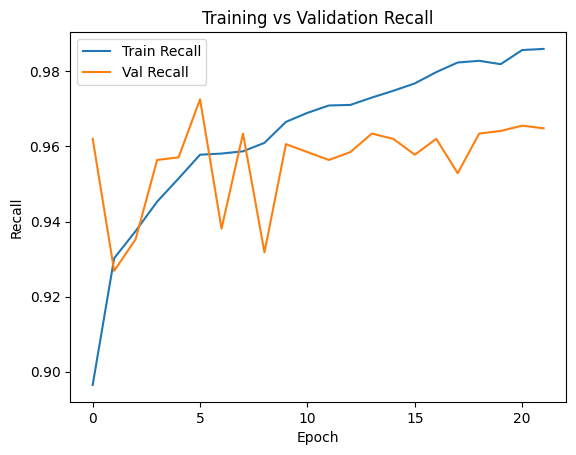

In [135]:
plt.figure()
plt.plot(history.history["recall"], label="Train Recall")
plt.plot(history.history["val_recall"], label="Val Recall")
plt.xlabel("Epoch")
plt.ylabel("Recall")
plt.title("Training vs Validation Recall")
plt.legend()
plt.show()

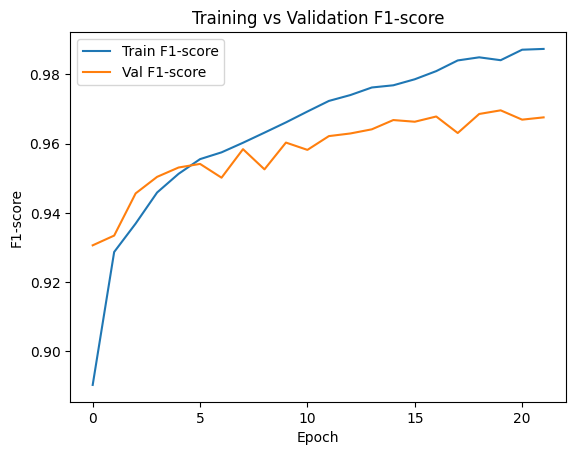

In [136]:
plt.figure()
plt.plot(f1, label="Train F1-score")
plt.plot(val_f1, label="Val F1-score")
plt.xlabel("Epoch")
plt.ylabel("F1-score")
plt.title("Training vs Validation F1-score")
plt.legend()
plt.show()

### **GRU**

In [64]:
import numpy as np
import hashlib
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, GRU, Dense, Dropout

# Build n-gram sequence (ordered)
def ngrams(url, n=3):
    url = str(url)
    if len(url) < n:
        return []
    return [url[i:i+n] for i in range(len(url)-n+1)]

# Hash n-grams into ids
VOCAB = 50000
PAD = 0
def to_id(s):
    h = hashlib.md5(s.encode("utf-8")).hexdigest()
    return (int(h, 16) % (VOCAB - 1)) + 1

MAX_LEN = 256

urls_train = df_train["url"].astype(str).values
urls_val   = df_val["url"].astype(str).values
urls_test  = df_test["url"].astype(str).values

y_train = (df_train["label"].astype(str).str.lower().values == "phish").astype(int)
y_val   = (df_val["label"].astype(str).str.lower().values == "phish").astype(int)
y_test  = (df_test["label"].astype(str).str.lower().values == "phish").astype(int)

X_train_gru = pad_sequences([[to_id(g) for g in ngrams(u, 3)] for u in urls_train],
                            maxlen=MAX_LEN, padding="post", truncating="post")
X_val_gru   = pad_sequences([[to_id(g) for g in ngrams(u, 3)] for u in urls_val],
                            maxlen=MAX_LEN, padding="post", truncating="post")
X_test_gru  = pad_sequences([[to_id(g) for g in ngrams(u, 3)] for u in urls_test],
                            maxlen=MAX_LEN, padding="post", truncating="post")

In [65]:
def build_gru_model(hp):
    lr = hp.Float("lr", min_value=1e-4, max_value=1e-2, sampling="log")

    model = Sequential([
        Embedding(VOCAB, 64, input_length=MAX_LEN, mask_zero=True),
        GRU(64, dropout=0.3, recurrent_dropout=0.0),
        Dropout(0.5),
        Dense(64, activation="relu", kernel_regularizer=tf.keras.regularizers.l2(1e-4), name="url_feat"),
        Dense(1, activation="sigmoid")
    ])

    model.compile(
        optimizer=Adam(learning_rate=lr),
        loss="binary_crossentropy",
        metrics=[
            "accuracy",
            tf.keras.metrics.Precision(name="precision"),
            tf.keras.metrics.Recall(name="recall"),
        ]
    )
    return model

In [66]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

In [67]:
tuner = kt.RandomSearch(
    hypermodel=build_gru_model,
    objective=kt.Objective("val_accuracy", direction="max"),  # keep accuracy as you prefer
    max_trials=10,
    executions_per_trial=1,
    directory="kt_runs",
    project_name="url_gru_randomsearch",
    overwrite=True,
    seed=42
)

/opt/anaconda3/envs/tf_fusion_py311/lib/python3.11/site-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [72]:
tuner.search(
    X_train_gru, y_train,
    validation_data=(X_val_gru, y_val),
    epochs=50,
    batch_size=tuner.oracle.hyperparameters.Choice("batch_size", [16, 32, 64]),
    callbacks=[early_stop],
    verbose=1
)

In [73]:
best_hp = tuner.get_best_hyperparameters(num_trials=1)[0]
print("Best hyperparameters:")
print("  lr:", best_hp.get("lr"))
print("  batch_size:", best_hp.get("batch_size"))

best_model = tuner.get_best_models(num_models=1)[0]

Best hyperparameters:
  lr: 0.005977728042983696
  batch_size: 32


In [145]:
# 1) Get best hyperparameters
best_hp = tuner.get_best_hyperparameters(1)[0]

# 2) Rebuild from scratch using the best hyperparameters
fresh_model = build_gru_model(best_hp)   

# 3) Train from scratch (this history is what you plot)
history = fresh_model.fit(
    X_train_gru, y_train,
    validation_data=(X_val_gru, y_val),
    epochs=50,  # max
    batch_size=best_hp.get("batch_size"),
    callbacks=[early_stop],
    verbose=1
)

# 4) Save + test
fresh_model.save("url_gru_patience.keras")
results = fresh_model.evaluate(X_test_gru, y_test, verbose=0, return_dict=True)
print(results)

Epoch 1/50


/opt/anaconda3/envs/tf_fusion_py311/lib/python3.11/site-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


430/430 ━━━━━━━━━━━━━━━━━━━━ 36s 81ms/step - accuracy: 0.9340 - loss: 0.1858 - precision: 0.9428 - recall: 0.9189 - val_accuracy: 0.9572 - val_loss: 0.1233 - val_precision: 0.9469 - val_recall: 0.9655
Epoch 2/50
430/430 ━━━━━━━━━━━━━━━━━━━━ 34s 78ms/step - accuracy: 0.9869 - loss: 0.0451 - precision: 0.9873 - recall: 0.9855 - val_accuracy: 0.9616 - val_loss: 0.1331 - val_precision: 0.9632 - val_recall: 0.9571
Epoch 3/50
430/430 ━━━━━━━━━━━━━━━━━━━━ 34s 80ms/step - accuracy: 0.9956 - loss: 0.0185 - precision: 0.9956 - recall: 0.9952 - val_accuracy: 0.9538 - val_loss: 0.2035 - val_precision: 0.9687 - val_recall: 0.9346
Epoch 4/50
430/430 ━━━━━━━━━━━━━━━━━━━━ 34s 79ms/step - accuracy: 0.9958 - loss: 0.0132 - precision: 0.9953 - recall: 0.9959 - val_accuracy: 0.9542 - val_loss: 0.2019 - val_precision: 0.9381 - val_recall: 0.9691
Epoch 5/50
430/430 ━━━━━━━━━━━━━━━━━━━━ 35s 81ms/step - accuracy: 0.9966 - loss: 0.0145 - precision: 0.9965 - recall: 0.9964 - val_accuracy: 0.9559 - val_loss: 0.1

In [76]:
fresh_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 256, 64)        │     3,200,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 64)             │        24,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ url_feat (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,687,557 (36.96 MB)

 Trainable params: 3,229,185 (12.32 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 6,458,372 (24.64 MB)

#### **Plot graph**

In [147]:
import numpy as np

precision = np.array(history.history["precision"])
recall = np.array(history.history["recall"])
val_precision = np.array(history.history["val_precision"])
val_recall = np.array(history.history["val_recall"])

f1 = 2 * (precision * recall) / (precision + recall + 1e-8)
val_f1 = 2 * (val_precision * val_recall) / (val_precision + val_recall + 1e-8)

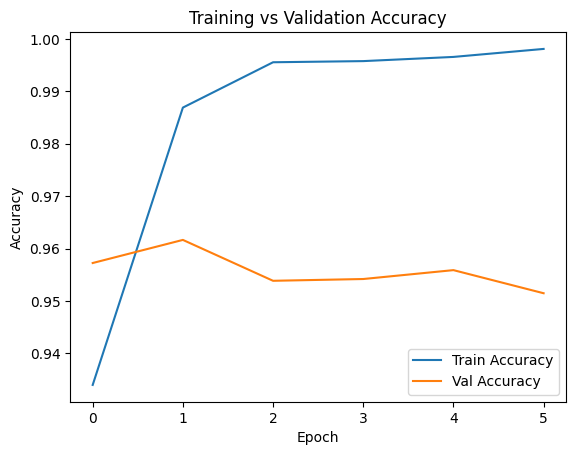

In [148]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Val Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.show()

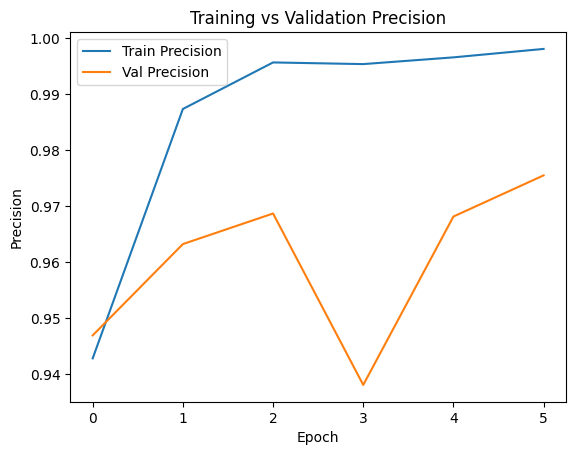

In [149]:
plt.figure()
plt.plot(history.history["precision"], label="Train Precision")
plt.plot(history.history["val_precision"], label="Val Precision")
plt.xlabel("Epoch")
plt.ylabel("Precision")
plt.title("Training vs Validation Precision")
plt.legend()
plt.show()

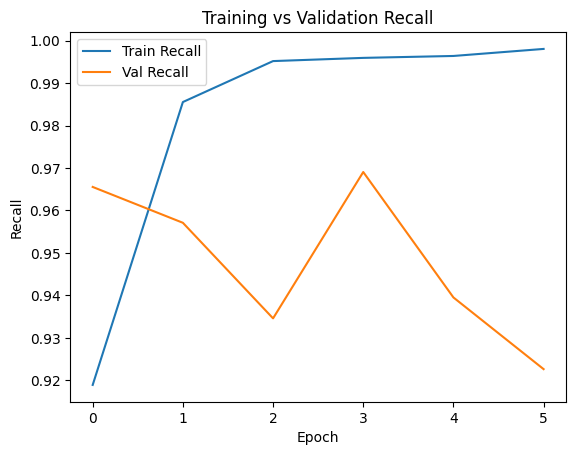

In [150]:
plt.figure()
plt.plot(history.history["recall"], label="Train Recall")
plt.plot(history.history["val_recall"], label="Val Recall")
plt.xlabel("Epoch")
plt.ylabel("Recall")
plt.title("Training vs Validation Recall")
plt.legend()
plt.show()

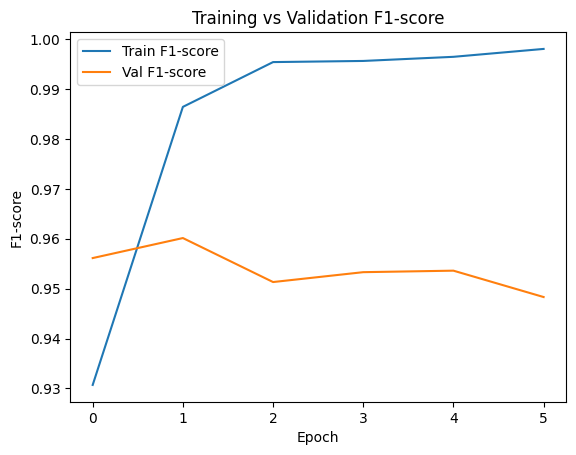

In [151]:
plt.figure()
plt.plot(f1, label="Train F1-score")
plt.plot(val_f1, label="Val F1-score")
plt.xlabel("Epoch")
plt.ylabel("F1-score")
plt.title("Training vs Validation F1-score")
plt.legend()
plt.show()

### **1D-CNN**

In [82]:
import numpy as np
import string
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Conv1D, MaxPooling1D, GlobalMaxPooling1D, Dense, Dropout

from sklearn.model_selection import train_test_split

urls_train = df_train["url"].astype(str).values
urls_val   = df_val["url"].astype(str).values
urls_test  = df_test["url"].astype(str).values

y_train = (df_train["label"] == "phish").astype(int).values
y_val   = (df_val["label"] == "phish").astype(int).values
y_test  = (df_test["label"] == "phish").astype(int).values


# Vocab (fixed char set)
characters = string.ascii_letters + string.digits + string.punctuation
PAD = 0
OOV = 1
char2idx = {c: i+2 for i, c in enumerate(characters)}  # start at 2
vocab_size = len(char2idx) + 2

MAX_LEN = 256

def encode_url(url):
    seq = [char2idx.get(c, OOV) for c in url]
    seq = seq[:MAX_LEN]
    return seq + [PAD] * (MAX_LEN - len(seq))

X_train_1dcnn = np.array([encode_url(u) for u in urls_train], dtype=np.int32)
X_val_1dcnn   = np.array([encode_url(u) for u in urls_val],   dtype=np.int32)
X_test_1dcnn  = np.array([encode_url(u) for u in urls_test],  dtype=np.int32)

In [83]:
def build_1dcnn_model(hp):
    lr = hp.Float("lr", min_value=1e-4, max_value=1e-2, sampling="log")

    model = Sequential([
        Embedding(input_dim=vocab_size, output_dim=32, input_length=MAX_LEN),
        Conv1D(128, 5, activation="relu"),
        MaxPooling1D(pool_size=2),
        Conv1D(128, 5, activation="relu"),
        GlobalMaxPooling1D(),
        Dense(64, activation="relu", name="url_feat"),
        Dropout(0.5),
        Dense(1, activation="sigmoid")
    ])

    model.compile(
        optimizer=Adam(learning_rate=lr),
        loss="binary_crossentropy",
        metrics=[
            "accuracy",
            tf.keras.metrics.Precision(name="precision"),
            tf.keras.metrics.Recall(name="recall"),
        ]
    )
    return model

In [84]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

In [85]:
tuner = kt.RandomSearch(
    hypermodel=build_1dcnn_model,
    objective=kt.Objective("val_accuracy", direction="max"),  # keep accuracy as your objective
    max_trials=10,
    executions_per_trial=1,
    directory="kt_runs",
    project_name="url_1dcnn_randomsearch",
    overwrite=True,
    seed=42
)

/opt/anaconda3/envs/tf_fusion_py311/lib/python3.11/site-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [87]:
tuner.search(
    X_train_1dcnn, y_train,
    validation_data=(X_val_1dcnn, y_val),
    epochs=50,
    batch_size=tuner.oracle.hyperparameters.Choice("batch_size", [16, 32, 64]),
    callbacks=[early_stop],
    verbose=1
)

In [88]:
best_hp = tuner.get_best_hyperparameters(num_trials=1)[0]
print("Best hyperparameters:")
print("  lr:", best_hp.get("lr"))
print("  batch_size:", best_hp.get("batch_size"))

Best hyperparameters:
  lr: 0.0009887195863122636
  batch_size: 16


In [154]:
final_model = build_1dcnn_model(best_hp)

history = final_model.fit(
    X_train_1dcnn, y_train,
    validation_data=(X_val_1dcnn, y_val),
    epochs=50,
    batch_size=best_hp.get("batch_size"),
    callbacks=[early_stop],
    verbose=1
)

final_model.save("url_1dcnn_patience.keras")

# -------------------------
# Test evaluation (safe printing)
# -------------------------
results = final_model.evaluate(X_test_1dcnn, y_test, verbose=0, return_dict=True)
print(results)

Epoch 1/50


/opt/anaconda3/envs/tf_fusion_py311/lib/python3.11/site-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


860/860 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - accuracy: 0.9012 - loss: 0.2302 - precision: 0.8849 - recall: 0.9143 - val_accuracy: 0.9603 - val_loss: 0.1082 - val_precision: 0.9704 - val_recall: 0.9466
Epoch 2/50
860/860 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.9644 - loss: 0.0977 - precision: 0.9658 - recall: 0.9604 - val_accuracy: 0.9535 - val_loss: 0.1293 - val_precision: 0.9292 - val_recall: 0.9782
Epoch 3/50
860/860 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.9736 - loss: 0.0756 - precision: 0.9731 - recall: 0.9721 - val_accuracy: 0.9657 - val_loss: 0.1004 - val_precision: 0.9527 - val_recall: 0.9775
Epoch 4/50
860/860 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.9808 - loss: 0.0558 - precision: 0.9827 - recall: 0.9774 - val_accuracy: 0.9654 - val_loss: 0.1086 - val_precision: 0.9825 - val_recall: 0.9451
Epoch 5/50
860/860 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.9855 - loss: 0.0420 - precision: 0.9862 - recall: 0.9836 - val_accuracy: 0.9688 - val_loss: 0.1049 - va

In [91]:
final_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 256, 32)        │         3,072 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 252, 128)       │        20,608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 126, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 122, 128)       │        82,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d_1          │ (None, 128)            │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ url_feat (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 342,149 (1.31 MB)

 Trainable params: 114,049 (445.50 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 228,100 (891.02 KB)

#### **Plot graph**

In [156]:
import numpy as np

precision = np.array(history.history["precision"])
recall = np.array(history.history["recall"])
val_precision = np.array(history.history["val_precision"])
val_recall = np.array(history.history["val_recall"])

f1 = 2 * (precision * recall) / (precision + recall + 1e-8)
val_f1 = 2 * (val_precision * val_recall) / (val_precision + val_recall + 1e-8)

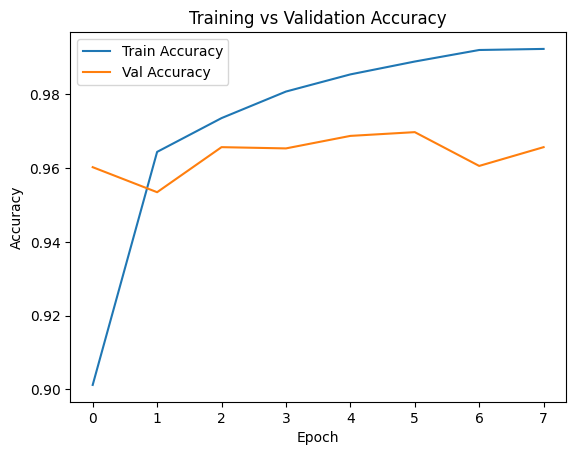

In [157]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Val Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.show()

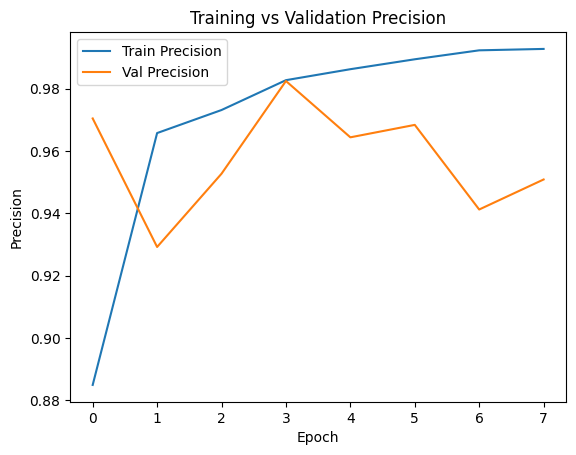

In [158]:
plt.figure()
plt.plot(history.history["precision"], label="Train Precision")
plt.plot(history.history["val_precision"], label="Val Precision")
plt.xlabel("Epoch")
plt.ylabel("Precision")
plt.title("Training vs Validation Precision")
plt.legend()
plt.show()

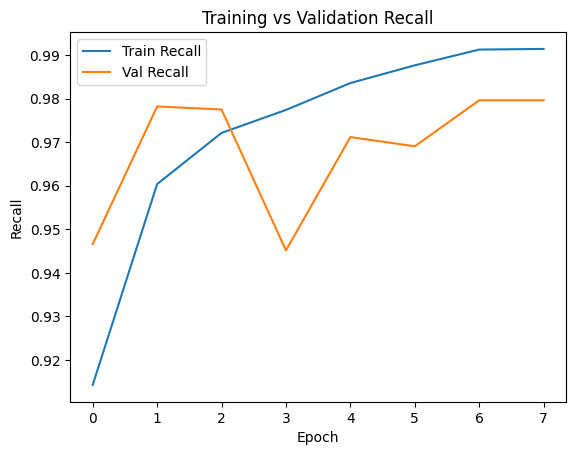

In [159]:
plt.figure()
plt.plot(history.history["recall"], label="Train Recall")
plt.plot(history.history["val_recall"], label="Val Recall")
plt.xlabel("Epoch")
plt.ylabel("Recall")
plt.title("Training vs Validation Recall")
plt.legend()
plt.show()

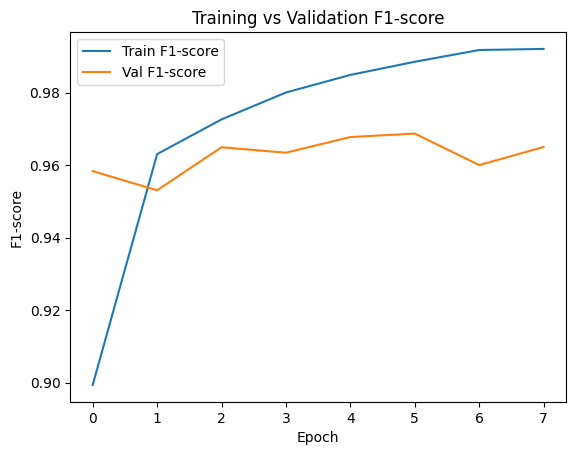

In [160]:
plt.figure()
plt.plot(f1, label="Train F1-score")
plt.plot(val_f1, label="Val F1-score")
plt.xlabel("Epoch")
plt.ylabel("F1-score")
plt.title("Training vs Validation F1-score")
plt.legend()
plt.show()

### **BiLSTM + BiGRU**

In [115]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Embedding, LSTM, GRU, Dense, Dropout, Concatenate, Bidirectional
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

# ===== Load =====
URL_COL = "url"
LABEL_COL = "label"

# (Assuming df_train, df_val, df_test already exist)
df_train[URL_COL] = df_train[URL_COL].astype(str).str.strip()
df_val[URL_COL]   = df_val[URL_COL].astype(str).str.strip()
df_test[URL_COL]  = df_test[URL_COL].astype(str).str.strip()

df_train[LABEL_COL] = df_train[LABEL_COL].astype(str).str.strip().str.lower()
df_val[LABEL_COL]   = df_val[LABEL_COL].astype(str).str.strip().str.lower()
df_test[LABEL_COL]  = df_test[LABEL_COL].astype(str).str.strip().str.lower()

urls_train = df_train[URL_COL].values
urls_val   = df_val[URL_COL].values
urls_test  = df_test[URL_COL].values

y_train = (df_train[LABEL_COL].values == "phish").astype(int)
y_val   = (df_val[LABEL_COL].values == "phish").astype(int)
y_test  = (df_test[LABEL_COL].values == "phish").astype(int)

# ===== Tokenise (TRAIN only) =====
MAX_LEN = 160  # use your 95% ~157 (less padding than 256)
tokenizer = Tokenizer(char_level=True, lower=False, oov_token="<OOV>")
tokenizer.fit_on_texts(urls_train)

X_train_lstmgru = pad_sequences(
    tokenizer.texts_to_sequences(urls_train),
    maxlen=MAX_LEN, padding="post", truncating="post"
)
X_val_lstmgru = pad_sequences(
    tokenizer.texts_to_sequences(urls_val),
    maxlen=MAX_LEN, padding="post", truncating="post"
)
X_test_lstmgru = pad_sequences(
    tokenizer.texts_to_sequences(urls_test),
    maxlen=MAX_LEN, padding="post", truncating="post"
)

vocab_size = len(tokenizer.word_index) + 1
print("vocab_size:", vocab_size)

vocab_size: 214


In [116]:
def build_lstmgru_model(hp):
    lr = hp.Float("lr", min_value=1e-4, max_value=1e-2, sampling="log")

    inp = Input(shape=(MAX_LEN,), name="url_seq")
    emb = Embedding(vocab_size, 64, input_length=MAX_LEN, mask_zero=True)(inp)

    # Branch 1: LSTM
    b1 = Bidirectional(LSTM(64, dropout=0.2, recurrent_dropout=0.0))(emb)

    # Branch 2: GRU
    b2 = Bidirectional(GRU(64, dropout=0.2, recurrent_dropout=0.0))(emb)

    x = Concatenate()([b1, b2])
    x = Dense(128, activation="relu")(x)
    x = Dropout(0.5)(x)
    x = Dense(64, activation="relu", name="url_feat")(x)
    x = Dropout(0.3)(x)
    out = Dense(1, activation="sigmoid")(x)

    model = Model(inp, out)

    model.compile(
        optimizer=Adam(learning_rate=lr),
        loss="binary_crossentropy",
        metrics=[
            "accuracy",
            tf.keras.metrics.Precision(name="precision"),
            tf.keras.metrics.Recall(name="recall"),
        ]
    )
    return model

In [117]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

In [118]:
tuner = kt.RandomSearch(
    hypermodel=build_lstmgru_model,
    objective=kt.Objective("val_accuracy", direction="max"),
    max_trials=10,
    executions_per_trial=1,
    directory="kt_runs",
    project_name="url_bilstm_bigru_randomsearch",
    overwrite=True,
    seed=42
)

/opt/anaconda3/envs/tf_fusion_py311/lib/python3.11/site-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [119]:
tuner.search(
    X_train_lstmgru, y_train,
    validation_data=(X_val_lstmgru, y_val),
    epochs=50,
    batch_size=tuner.oracle.hyperparameters.Choice("batch_size", [16, 32, 64]),
    callbacks=[early_stop],
    verbose=1
)

Trial 10 Complete [00h 18m 47s]
val_accuracy: 0.9585879445075989

Best val_accuracy So Far: 0.9680923223495483
Total elapsed time: 03h 07m 01s


In [120]:
best_hp = tuner.get_best_hyperparameters(num_trials=1)[0]
print("Best hyperparameters:")
print("  lr:", best_hp.get("lr"))
print("  batch_size:", best_hp.get("batch_size"))

Best hyperparameters:
  lr: 0.001450488633461591
  batch_size: 16


In [122]:
final_model = build_lstmgru_model(best_hp)

history = final_model.fit(
    X_train_lstmgru, y_train,
    validation_data=(X_val_lstmgru, y_val),
    epochs=50,
    batch_size=best_hp.get("batch_size"),
    callbacks=[early_stop],
    verbose=1
)

final_model.save("url_bilstm_bigru_best.keras")

# -------------------------
# Test evaluation (safe)
# -------------------------
results = final_model.evaluate(X_test_lstmgru, y_test, verbose=0, return_dict=True)
print(results)

Epoch 1/50
860/860 ━━━━━━━━━━━━━━━━━━━━ 129s 146ms/step - accuracy: 0.9121 - loss: 0.2278 - precision: 0.9021 - recall: 0.9176 - val_accuracy: 0.9477 - val_loss: 0.1511 - val_precision: 0.9391 - val_recall: 0.9536
Epoch 2/50
860/860 ━━━━━━━━━━━━━━━━━━━━ 133s 155ms/step - accuracy: 0.9470 - loss: 0.1492 - precision: 0.9455 - recall: 0.9445 - val_accuracy: 0.9389 - val_loss: 0.1616 - val_precision: 0.9265 - val_recall: 0.9487
Epoch 3/50
860/860 ━━━━━━━━━━━━━━━━━━━━ 133s 154ms/step - accuracy: 0.9518 - loss: 0.1345 - precision: 0.9496 - recall: 0.9507 - val_accuracy: 0.9494 - val_loss: 0.1346 - val_precision: 0.9286 - val_recall: 0.9698
Epoch 4/50
860/860 ━━━━━━━━━━━━━━━━━━━━ 132s 154ms/step - accuracy: 0.9573 - loss: 0.1264 - precision: 0.9561 - recall: 0.9554 - val_accuracy: 0.9538 - val_loss: 0.1289 - val_precision: 0.9490 - val_recall: 0.9557
Epoch 5/50
860/860 ━━━━━━━━━━━━━━━━━━━━ 131s 153ms/step - accuracy: 0.9610 - loss: 0.1085 - precision: 0.9613 - recall: 0.9578 - val_accuracy: 0

In [124]:
final_model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ url_seq             │ (None, 160)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_1         │ (None, 160, 64)   │     13,696 │ url_seq[0][0]     │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal_1         │ (None, 160)       │          0 │ url_seq[0][0]     │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_2     │ (None, 128)       │     66,048 │ embedding_1[0][0… │
│ (Bidirectional)     │                   │            │ not_equal_1[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_3     │ (None, 128)       │     49,920 │ embedding_1[0][0… │
│ (Bidirectional)     │                   │            │ not_equal_1[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 256)       │          0 │ bidirectional_2[… │
│ (Concatenate)       │                   │            │ bidirectional_3[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 128)       │     32,896 │ concatenate_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 128)       │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ url_feat (Dense)    │ (None, 64)        │      8,256 │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 64)        │          0 │ url_feat[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 1)         │         65 │ dropout_3[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 512,645 (1.96 MB)

 Trainable params: 170,881 (667.50 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 341,764 (1.30 MB)

#### **Plot graph**

In [125]:
import numpy as np

precision = np.array(history.history["precision"])
recall = np.array(history.history["recall"])
val_precision = np.array(history.history["val_precision"])
val_recall = np.array(history.history["val_recall"])

f1 = 2 * (precision * recall) / (precision + recall + 1e-8)
val_f1 = 2 * (val_precision * val_recall) / (val_precision + val_recall + 1e-8)

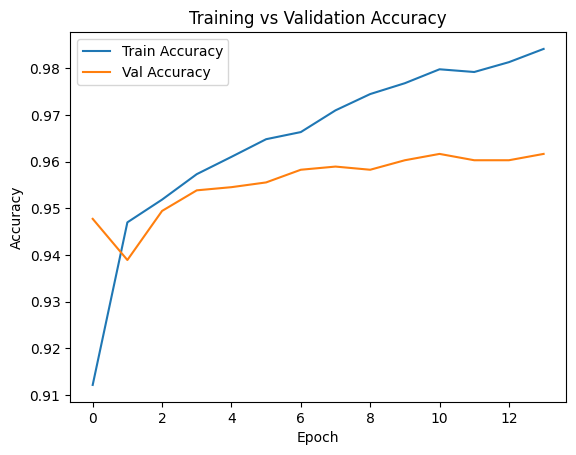

In [126]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Val Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.show()

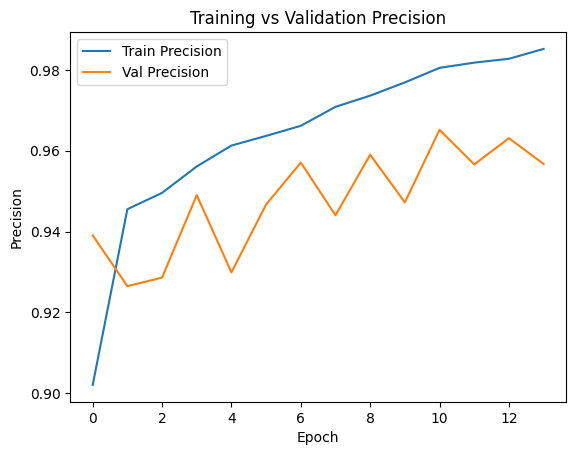

In [127]:
plt.figure()
plt.plot(history.history["precision"], label="Train Precision")
plt.plot(history.history["val_precision"], label="Val Precision")
plt.xlabel("Epoch")
plt.ylabel("Precision")
plt.title("Training vs Validation Precision")
plt.legend()
plt.show()

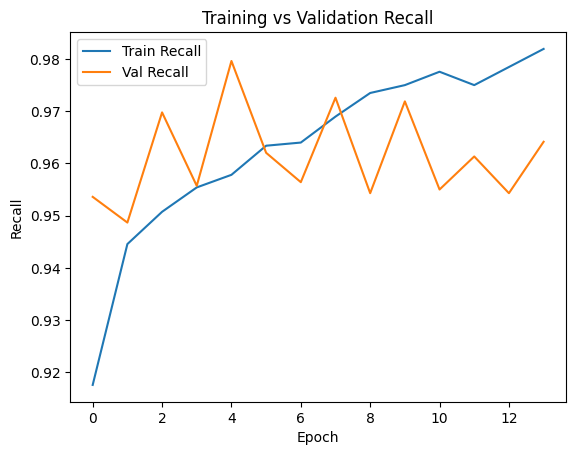

In [128]:
plt.figure()
plt.plot(history.history["recall"], label="Train Recall")
plt.plot(history.history["val_recall"], label="Val Recall")
plt.xlabel("Epoch")
plt.ylabel("Recall")
plt.title("Training vs Validation Recall")
plt.legend()
plt.show()

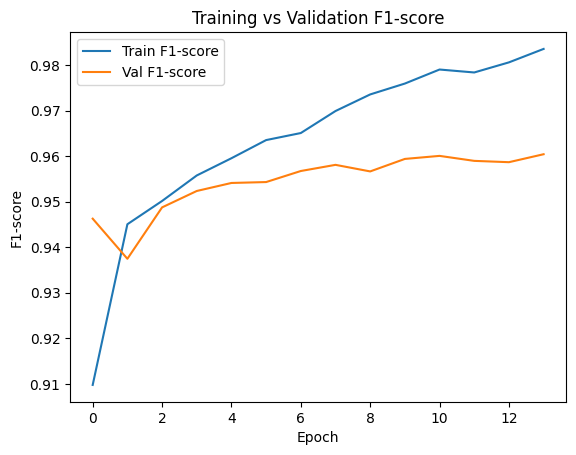

In [129]:
plt.figure()
plt.plot(f1, label="Train F1-score")
plt.plot(val_f1, label="Val F1-score")
plt.xlabel("Epoch")
plt.ylabel("F1-score")
plt.title("Training vs Validation F1-score")
plt.legend()
plt.show()

### **DenseNet**

In [97]:
import tensorflow as tf
from tensorflow.keras.applications.densenet import DenseNet121
from tensorflow.keras.layers import Input, GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

IMG_SIZE = (224, 224)

def build_densenet_frozen(hp):
    lr = hp.Float("lr", min_value=1e-5, max_value=1e-3, sampling="log")

    inp = Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 3))
    base = DenseNet121(include_top=False, weights="imagenet", input_tensor=inp)

    # Phase 1: freeze backbone
    base.trainable = False

    x = GlobalAveragePooling2D()(base.output)
    x = Dropout(0.5)(x)
    feat = Dense(128, activation="relu", name="img_feat")(x)
    x = Dropout(0.5)(feat)
    out = Dense(1, activation="sigmoid")(x)

    model = Model(inp, out)
    model.compile(
        optimizer=Adam(learning_rate=lr),
        loss="binary_crossentropy",
        metrics=[
            "accuracy",
            tf.keras.metrics.Precision(name="precision"),
            tf.keras.metrics.Recall(name="recall")
        ]
    )
    return model

In [98]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss", patience=5, restore_best_weights=True
)

In [99]:
tuner = kt.RandomSearch(
    hypermodel=build_densenet_frozen,
    objective=kt.Objective("val_accuracy", direction="max"),
    max_trials=5,                 # ✅ keep small (DenseNet expensive)
    executions_per_trial=1,
    directory="kt_runs",
    project_name="densenet_frozen_randomsearch",
    overwrite=True,
    seed=42
)

In [100]:
tuner.search(
    X_train_img, y_train,
    validation_data=(X_val_img, y_val),
    epochs=20,
    batch_size=tuner.oracle.hyperparameters.Choice("batch_size", [4, 8, 16]),
    callbacks=[early_stop],
    verbose=1
)

Trial 5 Complete [03h 43m 48s]
val_accuracy: 0.8649015426635742

Best val_accuracy So Far: 0.8696537613868713
Total elapsed time: 14h 55m 00s


In [101]:
best_hp = tuner.get_best_hyperparameters(1)[0]
print("Best lr:", best_hp.get("lr"))
print("Best batch_size:", best_hp.get("batch_size"))

Best lr: 0.00019004375238737127
Best batch_size: 4


In [106]:
import tensorflow as tf
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.layers import Input, GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

IMG_SIZE = (224, 224)

def build_densenet_frozen(hp):
    lr = float(hp.get("lr")) if hasattr(hp, "get") else float(hp)

    inp = Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 3))

    base = DenseNet121(include_top=False, weights="imagenet", input_shape=(224,224,3))
    base.trainable = False

    # ✅ IMPORTANT: force BN to inference mode for frozen backbone
    x = base(inp, training=False)

    x = GlobalAveragePooling2D()(x)
    x = Dropout(0.5)(x)
    feat = Dense(128, activation="relu", name="img_feat")(x)
    x = Dropout(0.5)(feat)
    out = Dense(1, activation="sigmoid")(x)

    model = Model(inp, out)
    model.compile(
        optimizer=Adam(learning_rate=lr),
        loss="binary_crossentropy",
        metrics=["accuracy",
                 tf.keras.metrics.Precision(name="precision"),
                 tf.keras.metrics.Recall(name="recall")]
    )
    return model


In [107]:
tf.keras.backend.clear_session()
final_model = build_densenet_frozen(best_hp)

history = final_model.fit(
    X_train_img.astype("float32"), y_train.astype("int32"),
    validation_data=(X_val_img.astype("float32"), y_val.astype("int32")),
    epochs=50,
    batch_size=int(best_hp.get("batch_size")),
    callbacks=[early_stop],
    verbose=1
)

final_model.save("densenet_frozen_best.keras")
results = final_model.evaluate(X_test_img, y_test, verbose=0, return_dict=True)
print(results)

Epoch 1/50
3437/3437 ━━━━━━━━━━━━━━━━━━━━ 679s 195ms/step - accuracy: 0.7400 - loss: 0.5466 - precision: 0.7416 - recall: 0.7083 - val_accuracy: 0.8198 - val_loss: 0.4472 - val_precision: 0.8596 - val_recall: 0.7489
Epoch 2/50
3437/3437 ━━━━━━━━━━━━━━━━━━━━ 633s 184ms/step - accuracy: 0.7933 - loss: 0.4717 - precision: 0.8054 - recall: 0.7539 - val_accuracy: 0.8265 - val_loss: 0.4157 - val_precision: 0.8825 - val_recall: 0.7391
Epoch 3/50
3437/3437 ━━━━━━━━━━━━━━━━━━━━ 627s 183ms/step - accuracy: 0.7984 - loss: 0.4528 - precision: 0.8184 - recall: 0.7485 - val_accuracy: 0.8327 - val_loss: 0.4081 - val_precision: 0.8666 - val_recall: 0.7722
Epoch 4/50
3437/3437 ━━━━━━━━━━━━━━━━━━━━ 624s 182ms/step - accuracy: 0.8049 - loss: 0.4407 - precision: 0.8259 - recall: 0.7550 - val_accuracy: 0.8360 - val_loss: 0.3979 - val_precision: 0.9072 - val_recall: 0.7356
Epoch 5/50
3437/3437 ━━━━━━━━━━━━━━━━━━━━ 609s 177ms/step - accuracy: 0.8100 - loss: 0.4292 - precision: 0.8304 - recall: 0.7621 - val_a

In [109]:
final_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ densenet121 (Functional)        │ (None, 7, 7, 1024)     │     7,037,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1024)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ img_feat (Dense)                │ (None, 128)            │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,431,493 (28.35 MB)

 Trainable params: 131,329 (513.00 KB)

 Non-trainable params: 7,037,504 (26.85 MB)

 Optimizer params: 262,660 (1.00 MB)

#### **Plot graph**

In [110]:
import numpy as np

precision = np.array(history.history["precision"])
recall = np.array(history.history["recall"])
val_precision = np.array(history.history["val_precision"])
val_recall = np.array(history.history["val_recall"])

f1 = 2 * (precision * recall) / (precision + recall + 1e-8)
val_f1 = 2 * (val_precision * val_recall) / (val_precision + val_recall + 1e-8)

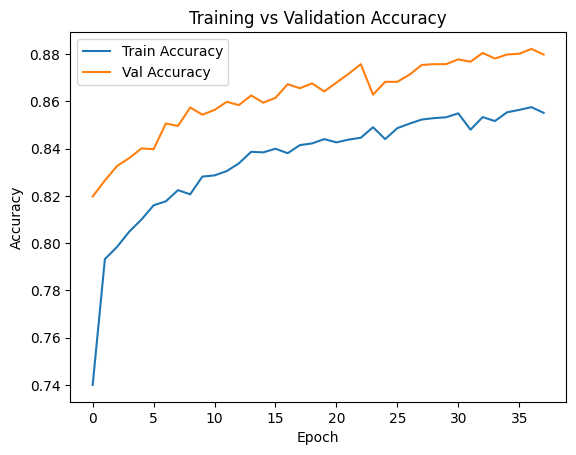

In [111]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Val Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.show()

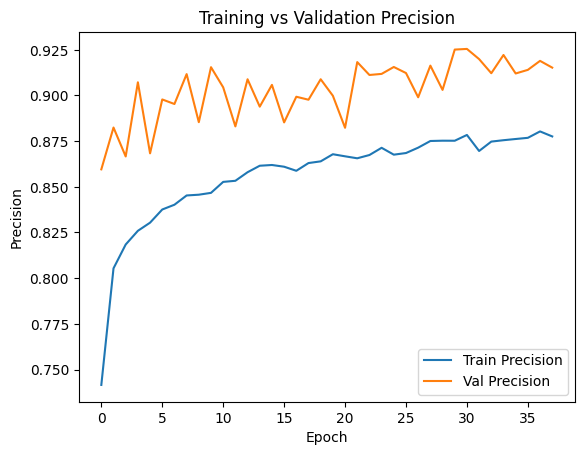

In [112]:
plt.figure()
plt.plot(history.history["precision"], label="Train Precision")
plt.plot(history.history["val_precision"], label="Val Precision")
plt.xlabel("Epoch")
plt.ylabel("Precision")
plt.title("Training vs Validation Precision")
plt.legend()
plt.show()

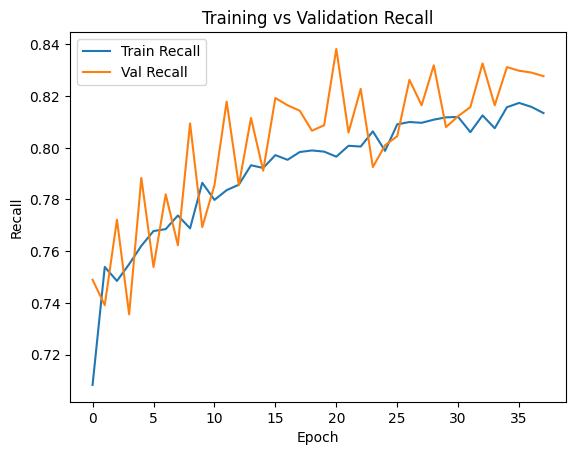

In [113]:
plt.figure()
plt.plot(history.history["recall"], label="Train Recall")
plt.plot(history.history["val_recall"], label="Val Recall")
plt.xlabel("Epoch")
plt.ylabel("Recall")
plt.title("Training vs Validation Recall")
plt.legend()
plt.show()

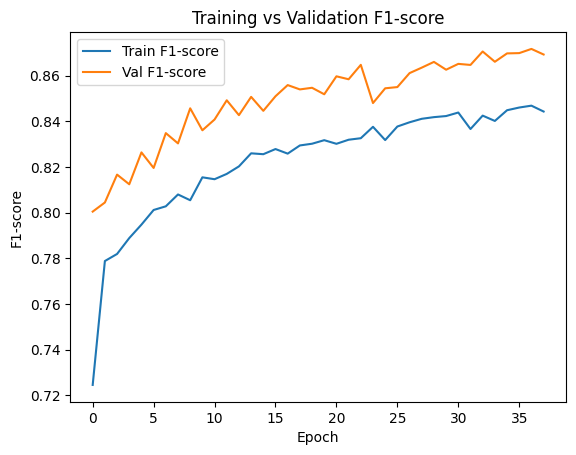

In [114]:
plt.figure()
plt.plot(f1, label="Train F1-score")
plt.plot(val_f1, label="Val F1-score")
plt.xlabel("Epoch")
plt.ylabel("F1-score")
plt.title("Training vs Validation F1-score")
plt.legend()
plt.show()

### **Feature Extraction**

In [162]:
import tensorflow as tf
from tensorflow.keras.layers import Input
from tensorflow.keras.models import Model
import numpy as np
import keras
from keras.models import Model

def load_encoder_connected(path, feat_layer, input_len, name, dtype="int32"):
    m = keras.models.load_model(path)

    # 1) force-build the graph (VERY IMPORTANT)
    dummy = np.zeros((1, input_len), dtype=dtype)
    _ = m.predict(dummy, verbose=0)

    # 2) now build encoder from the model's OWN graph tensors
    enc = Model(inputs=m.inputs, outputs=m.get_layer(feat_layer).output, name=name)
    enc.trainable = False
    return enc

In [163]:
url_encoders = {
    "bigru":  load_encoder_connected("url_bigru_patience.keras",        "url_feat", 256, "enc_bigru"),
    "bilstm": load_encoder_connected("url_bilstm_patience.keras",       "url_feat", 256, "enc_bilstm"),
    "gru":    load_encoder_connected("url_gru_patience.keras",          "url_feat", 256, "enc_gru"),
    "1dcnn":  load_encoder_connected("url_1dcnn_patience.keras",        "url_feat", 256, "enc_1dcnn"),
    "bilstm_bigru": load_encoder_connected("url_bilstm_bigru_best.keras", "url_feat", 160, "enc_bilstm_bigru"),
}

In [164]:
for k, enc in url_encoders.items():
    print(k, enc.input_shape, "->", enc.output_shape)

bigru (None, 256) -> (None, 64)
bilstm (None, 256) -> (None, 64)
gru (None, 256) -> (None, 64)
1dcnn (None, 256) -> (None, 64)
bilstm_bigru (None, 160) -> (None, 64)


In [165]:
import numpy as np
import keras
from keras.models import Model

def load_img_encoder(path, feat_layer="img_feat", name="enc_img"):
    m = keras.models.load_model(path)

    # force-build graph with correct image dummy input
    _ = m.predict(np.zeros((1,224,224,3), dtype="float32"), verbose=0)

    enc = Model(inputs=m.inputs, outputs=m.get_layer(feat_layer).output, name=name)
    enc.trainable = False
    return enc

img_encoder = load_img_encoder("densenet_frozen_best.keras", "img_feat", "enc_img")
print("img_encoder output:", img_encoder.output_shape)

img_encoder output: (None, 128)


In [166]:
print("IMG model input:", img_encoder.input_shape)
print("IMG model output:", img_encoder.output_shape)

IMG model input: (None, 224, 224, 3)
IMG model output: (None, 128)


In [170]:
U = {}

for name, enc in url_encoders.items():
    print(f"Extracting URL features: {name}")

    if name == "gru":
        Xtr, Xva, Xte = X_train_gru, X_val_gru, X_test_gru
    elif name == "1dcnn":
        Xtr, Xva, Xte = X_train_1dcnn, X_val_1dcnn, X_test_1dcnn
    elif name == "bilstm_bigru":
        Xtr, Xva, Xte = X_train_lstmgru, X_val_lstmgru, X_test_lstmgru
    else:  # bigru / bilstm
        Xtr, Xva, Xte = X_train_url, X_val_url, X_test_url

    U[f"{name}_train"] = enc.predict(Xtr, batch_size=256, verbose=1)
    U[f"{name}_val"]   = enc.predict(Xva, batch_size=256, verbose=1)
    U[f"{name}_test"]  = enc.predict(Xte, batch_size=256, verbose=1)

    print(U[f"{name}_train"].shape)

Extracting URL features: bigru
54/54 ━━━━━━━━━━━━━━━━━━━━ 7s 122ms/step
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 106ms/step
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 136ms/step
(13748, 64)
Extracting URL features: bilstm
54/54 ━━━━━━━━━━━━━━━━━━━━ 12s 221ms/step
12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 215ms/step
12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 212ms/step
(13748, 64)
Extracting URL features: gru
54/54 ━━━━━━━━━━━━━━━━━━━━ 5s 93ms/step
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 87ms/step
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 89ms/step
(13748, 64)
Extracting URL features: 1dcnn
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
(13748, 64)
Extracting URL features: bilstm_bigru
54/54 ━━━━━━━━━━━━━━━━━━━━ 7s 121ms/step
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 113ms/step
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 115ms/step
(13748, 64)


In [175]:
V_train = img_encoder.predict(X_train_img, batch_size=16, verbose=1)
V_val   = img_encoder.predict(X_val_img,   batch_size=16, verbose=1)
V_test  = img_encoder.predict(X_test_img,  batch_size=16, verbose=1)

860/860 ━━━━━━━━━━━━━━━━━━━━ 342s 396ms/step
185/185 ━━━━━━━━━━━━━━━━━━━━ 78s 421ms/step
185/185 ━━━━━━━━━━━━━━━━━━━━ 79s 427ms/step


In [176]:
import keras_tuner as kt
import tensorflow as tf
from tensorflow.keras import layers, Model

def build_fusion_head_tunable(hp, url_dim=64, img_dim=128, name="fusion_head"):
    lr = hp.Float("lr", 1e-4, 1e-2, sampling="log")

    u_in = tf.keras.Input(shape=(url_dim,), name="url_feat_in")
    v_in = tf.keras.Input(shape=(img_dim,), name="img_feat_in")

    x = layers.Concatenate()([u_in, v_in])
    x = layers.Dense(256, activation="relu")(x)
    x = layers.Dropout(0.5)(x)
    x = layers.Dense(64, activation="relu")(x)
    x = layers.Dropout(0.3)(x)
    out = layers.Dense(1, activation="sigmoid")(x)

    model = Model([u_in, v_in], out, name=name)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
        loss="binary_crossentropy",
        metrics=[
            "accuracy",
            tf.keras.metrics.Precision(name="precision"),
            tf.keras.metrics.Recall(name="recall"),
            tf.keras.metrics.AUC(name="auc"),
        ]
    )
    return model

In [177]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss", patience=5, restore_best_weights=True
)

In [178]:
def tune_and_train_fusion(name, Utr, Uva, Ute, V_train, V_val, V_test, y_train, y_val, y_test):

    assert Utr.shape[0] == V_train.shape[0] == len(y_train)
    assert Uva.shape[0] == V_val.shape[0] == len(y_val)
    assert Ute.shape[0] == V_test.shape[0] == len(y_test)
    
    tuner = kt.RandomSearch(
        hypermodel=lambda hp: build_fusion_head_tunable(hp, 64, 128, name=f"fusion_{name}"),
        objective=kt.Objective("val_accuracy", direction="max"),
        max_trials=10,
        executions_per_trial=1,
        directory="kt_runs",
        project_name=f"fusion_{name}_randomsearch",
        overwrite=True,
        seed=42
    )

    tuner.search(
        [Utr, V_train], y_train,
        validation_data=([Uva, V_val], y_val),
        epochs=50,
        batch_size=tuner.oracle.hyperparameters.Choice("batch_size", [32, 64, 128]),
        callbacks=[early_stop],
        verbose=1
    )

    best_hp = tuner.get_best_hyperparameters(1)[0]
    print(f"[{name}] Best lr={best_hp.get('lr')}, best batch={best_hp.get('batch_size')}")

    # Rebuild fresh for clean curves
    final_model = build_fusion_head_tunable(best_hp, 64, 128, name=f"fusion_{name}_best")
    history = final_model.fit(
        [Utr, V_train], y_train,
        validation_data=([Uva, V_val], y_val),
        epochs=50,
        batch_size=best_hp.get("batch_size"),
        callbacks=[early_stop],
        verbose=1
    )

    results = final_model.evaluate([Ute, V_test], y_test, verbose=0, return_dict=True)
    final_model.save(f"fusion_{name}_best.keras")
    return history, results, best_hp

In [179]:
import gc

fusion_sets = {
    "bigru_densenet":        (U["bigru_train"],        U["bigru_val"],        U["bigru_test"]),
    "bilstm_densenet":       (U["bilstm_train"],       U["bilstm_val"],       U["bilstm_test"]),
    "gru_densenet":          (U["gru_train"],          U["gru_val"],          U["gru_test"]),
    "1dcnn_densenet":        (U["1dcnn_train"],        U["1dcnn_val"],        U["1dcnn_test"]),
    "bilstm_bigru_densenet": (U["bilstm_bigru_train"], U["bilstm_bigru_val"], U["bilstm_bigru_test"]),
}

fusion_results = {}
fusion_histories = {}
fusion_hps = {}

for name, (Utr, Uva, Ute) in fusion_sets.items():
    tf.keras.backend.clear_session()
    gc.collect()

    history, res, hp = tune_and_train_fusion(
        name, Utr, Uva, Ute,
        V_train, V_val, V_test,
        y_train, y_val, y_test
    )

    fusion_histories[name] = history
    fusion_results[name] = res
    fusion_hps[name] = {"lr": hp.get("lr"), "batch_size": hp.get("batch_size")}

    print(name, res)

Trial 10 Complete [00h 00m 06s]
val_accuracy: 0.9704684615135193

Best val_accuracy So Far: 0.9704684615135193
Total elapsed time: 00h 01m 00s
[bilstm_bigru_densenet] Best lr=0.0006562536901904111, best batch=32
Epoch 1/50
430/430 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9807 - auc: 0.9975 - loss: 0.0533 - precision: 0.9840 - recall: 0.9757 - val_accuracy: 0.9664 - val_auc: 0.9913 - val_loss: 0.1218 - val_precision: 0.9603 - val_recall: 0.9705
Epoch 2/50
430/430 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9873 - auc: 0.9979 - loss: 0.0423 - precision: 0.9875 - recall: 0.9863 - val_accuracy: 0.9684 - val_auc: 0.9909 - val_loss: 0.1128 - val_precision: 0.9657 - val_recall: 0.9691
Epoch 3/50
430/430 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9867 - auc: 0.9982 - loss: 0.0387 - precision: 0.9864 - recall: 0.9860 - val_accuracy: 0.9705 - val_auc: 0.9930 - val_loss: 0.1018 - val_precision: 0.9691 - val_recall: 0.9698
Epoch 4/50
430/430 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy

In [182]:
print("\n===== Fusion Models: Best Hyperparameters & Test Results =====")

for name in fusion_results.keys():
    print(f"\n🔹 Fusion model: {name}")

    print("  Best Hyperparameters:")
    for k, v in fusion_hps[name].items():
        print(f"    {k}: {v}")

    print("  Test Results:")
    for metric, value in fusion_results[name].items():
        print(f"    {metric}: {value:.4f}")


===== Fusion Models: Best Hyperparameters & Test Results =====

🔹 Fusion model: bigru_densenet
  Best Hyperparameters:
    lr: 0.005977728042983696
    batch_size: 64
  Test Results:
    accuracy: 0.9766
    auc: 0.9924
    loss: 0.0939
    precision: 0.9815
    recall: 0.9698

🔹 Fusion model: bilstm_densenet
  Best Hyperparameters:
    lr: 0.00905127409782462
    batch_size: 64
  Test Results:
    accuracy: 0.9762
    auc: 0.9910
    loss: 0.1216
    precision: 0.9794
    recall: 0.9712

🔹 Fusion model: gru_densenet
  Best Hyperparameters:
    lr: 0.005977728042983696
    batch_size: 64
  Test Results:
    accuracy: 0.9572
    auc: 0.9854
    loss: 0.1653
    precision: 0.9432
    recall: 0.9698

🔹 Fusion model: 1dcnn_densenet
  Best Hyperparameters:
    lr: 0.00905127409782462
    batch_size: 64
  Test Results:
    accuracy: 0.9759
    auc: 0.9909
    loss: 0.1315
    precision: 0.9781
    recall: 0.9719

🔹 Fusion model: bilstm_bigru_densenet
  Best Hyperparameters:
    lr: 0.000656

In [188]:
print("\n===== Fusion Models: Best Hyperparameters & Test Results =====")

for name in fusion_results.keys():
    print(f"\n🔹 Fusion model: {name}")

    print("  Best Hyperparameters:")
    for k, v in fusion_hps[name].items():
        print(f"    {k}: {v}")

    print("  Test Results:")

    # Extract metrics
    loss = fusion_results[name]["loss"]
    acc = fusion_results[name]["accuracy"]
    prec = fusion_results[name]["precision"]
    rec = fusion_results[name]["recall"]
    auc = fusion_results[name]["auc"]

    # Compute F1
    f1 = 2 * (prec * rec) / (prec + rec + 1e-8)

    print(f"    loss      : {loss:.4f}")
    print(f"    accuracy  : {acc:.4f}")
    print(f"    precision : {prec:.4f}")
    print(f"    recall    : {rec:.4f}")
    print(f"    F1-score  : {f1:.4f}")
    print(f"    AUC       : {auc:.4f}")


===== Fusion Models: Best Hyperparameters & Test Results =====

🔹 Fusion model: bigru_densenet
  Best Hyperparameters:
    lr: 0.005977728042983696
    batch_size: 64
  Test Results:
    loss      : 0.0939
    accuracy  : 0.9766
    precision : 0.9815
    recall    : 0.9698
    F1-score  : 0.9756
    AUC       : 0.9924

🔹 Fusion model: bilstm_densenet
  Best Hyperparameters:
    lr: 0.00905127409782462
    batch_size: 64
  Test Results:
    loss      : 0.1216
    accuracy  : 0.9762
    precision : 0.9794
    recall    : 0.9712
    F1-score  : 0.9753
    AUC       : 0.9910

🔹 Fusion model: gru_densenet
  Best Hyperparameters:
    lr: 0.005977728042983696
    batch_size: 64
  Test Results:
    loss      : 0.1653
    accuracy  : 0.9572
    precision : 0.9432
    recall    : 0.9698
    F1-score  : 0.9563
    AUC       : 0.9854

🔹 Fusion model: 1dcnn_densenet
  Best Hyperparameters:
    lr: 0.00905127409782462
    batch_size: 64
  Test Results:
    loss      : 0.1315
    accuracy  : 0.9759

In [191]:
print("Epochs trained for fusion models (early stopping):\n")

for name, history in fusion_histories.items():
    epochs_trained = len(history.history["loss"])
    print(f"{name}: {epochs_trained} epochs")


Epochs trained for fusion models (early stopping):

bigru_densenet: 8 epochs
bilstm_densenet: 5 epochs
gru_densenet: 5 epochs
1dcnn_densenet: 5 epochs
bilstm_bigru_densenet: 10 epochs


In [183]:
import numpy as np
import matplotlib.pyplot as plt

fusion_titles = {
    "bigru_densenet": "BiGRU + DenseNet (Fusion)",
    "bilstm_densenet": "BiLSTM + DenseNet (Fusion)",
    "gru_densenet": "GRU + DenseNet (Fusion)",
    "1dcnn_densenet": "1D-CNN + DenseNet (Fusion)",
    "bilstm_bigru_densenet": "BiLSTM + BiGRU + DenseNet (Fusion)",
}

In [185]:
import numpy as np
import matplotlib.pyplot as plt

def plot_fusion_curves(history, title="Fusion"):
    h = history.history

    # Metrics
    acc, val_acc = h["accuracy"], h["val_accuracy"]
    pre, val_pre = h["precision"], h["val_precision"]
    rec, val_rec = h["recall"], h["val_recall"]

    # F1 from precision & recall
    pre_np, rec_np = np.array(pre), np.array(rec)
    val_pre_np, val_rec_np = np.array(val_pre), np.array(val_rec)

    f1 = 2 * (pre_np * rec_np) / (pre_np + rec_np + 1e-8)
    val_f1 = 2 * (val_pre_np * val_rec_np) / (val_pre_np + val_rec_np + 1e-8)

    epochs = np.arange(1, len(acc) + 1)

    # ---- 4 subplots in ONE figure ----
    fig, axs = plt.subplots(2, 2, figsize=(12, 8))
    fig.suptitle(title, fontsize=14)

    # Accuracy
    axs[0, 0].plot(epochs, acc, label="train")
    axs[0, 0].plot(epochs, val_acc, label="val")
    axs[0, 0].set_title("Accuracy")
    axs[0, 0].set_xlabel("Epoch")
    axs[0, 0].set_ylabel("Accuracy")
    axs[0, 0].legend()

    # Precision
    axs[0, 1].plot(epochs, pre, label="train")
    axs[0, 1].plot(epochs, val_pre, label="val")
    axs[0, 1].set_title("Precision")
    axs[0, 1].set_xlabel("Epoch")
    axs[0, 1].set_ylabel("Precision")
    axs[0, 1].legend()

    # Recall
    axs[1, 0].plot(epochs, rec, label="train")
    axs[1, 0].plot(epochs, val_rec, label="val")
    axs[1, 0].set_title("Recall")
    axs[1, 0].set_xlabel("Epoch")
    axs[1, 0].set_ylabel("Recall")
    axs[1, 0].legend()

    # F1-score
    axs[1, 1].plot(epochs, f1, label="train")
    axs[1, 1].plot(epochs, val_f1, label="val")
    axs[1, 1].set_title("F1-score")
    axs[1, 1].set_xlabel("Epoch")
    axs[1, 1].set_ylabel("F1-score")
    axs[1, 1].legend()

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()


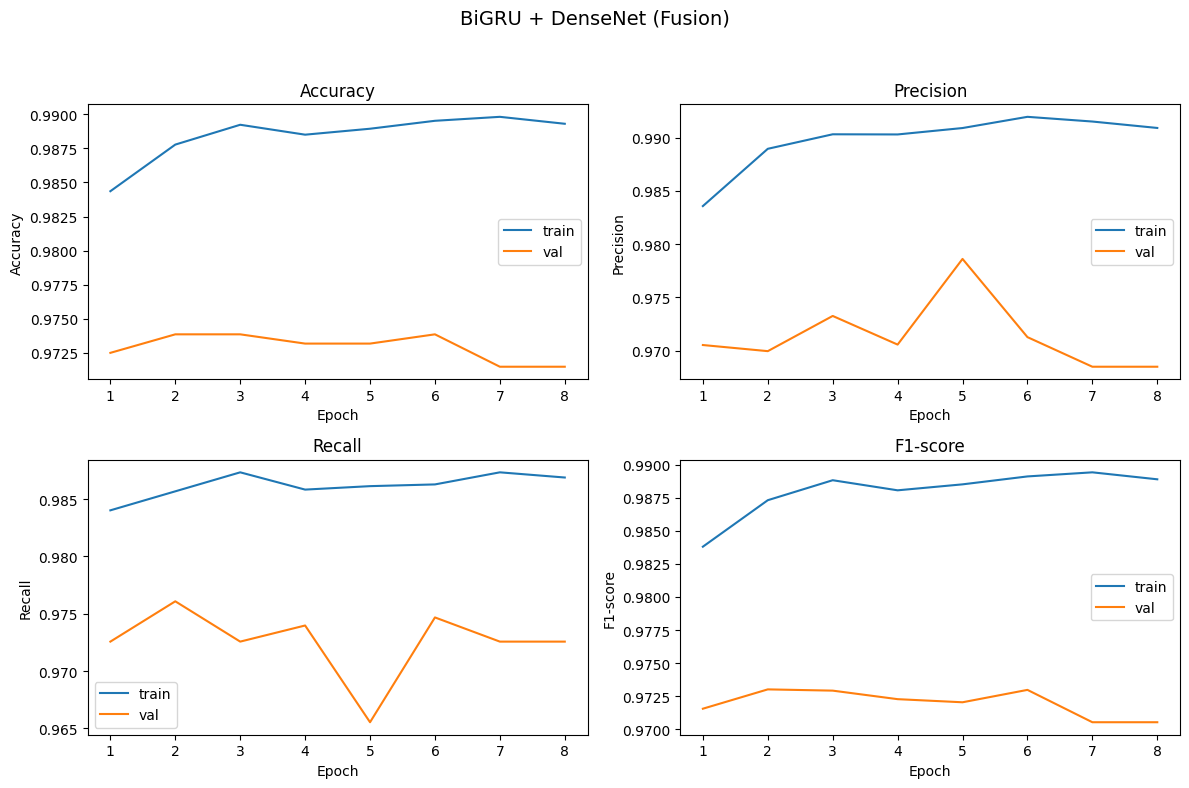

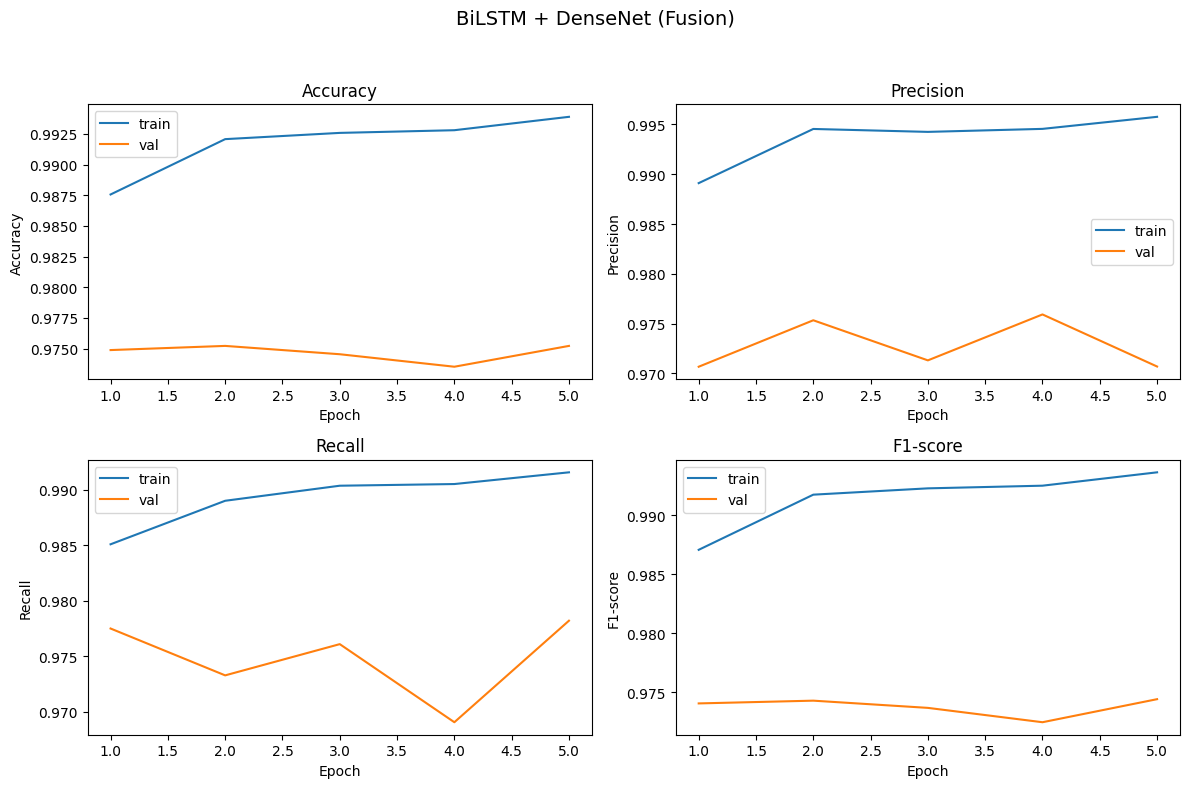

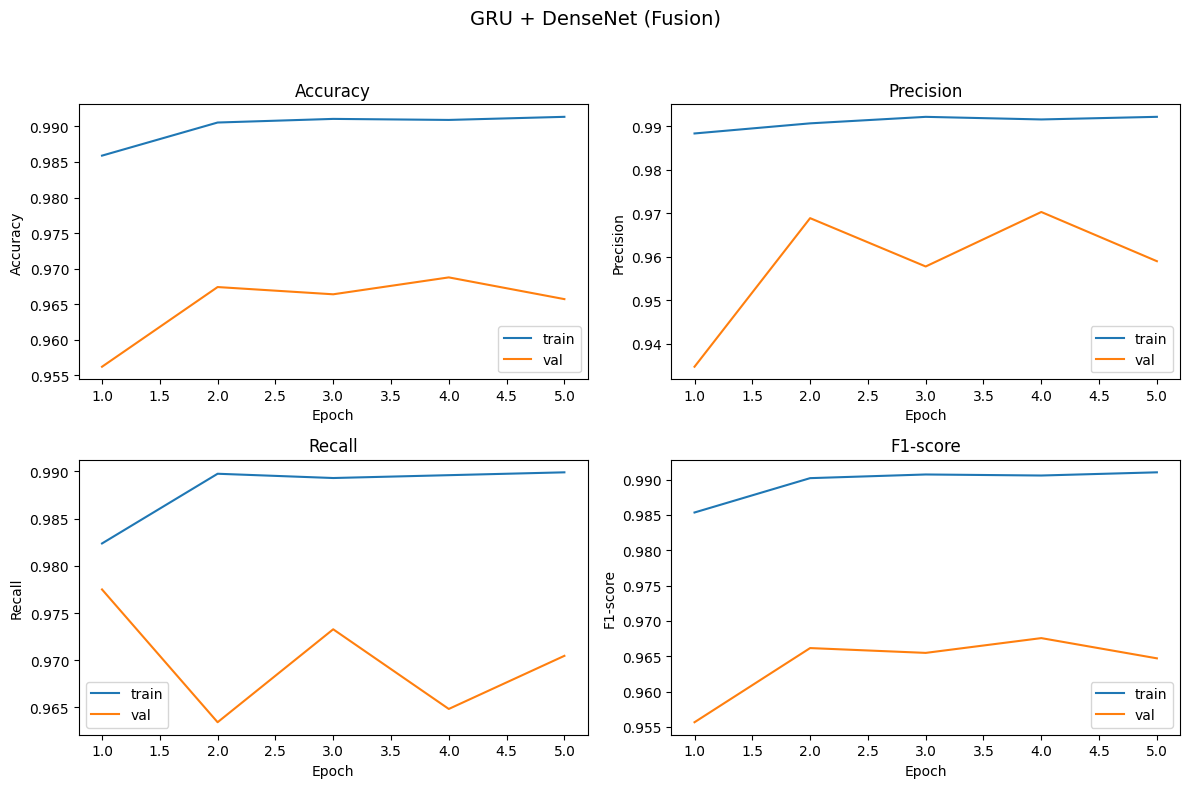

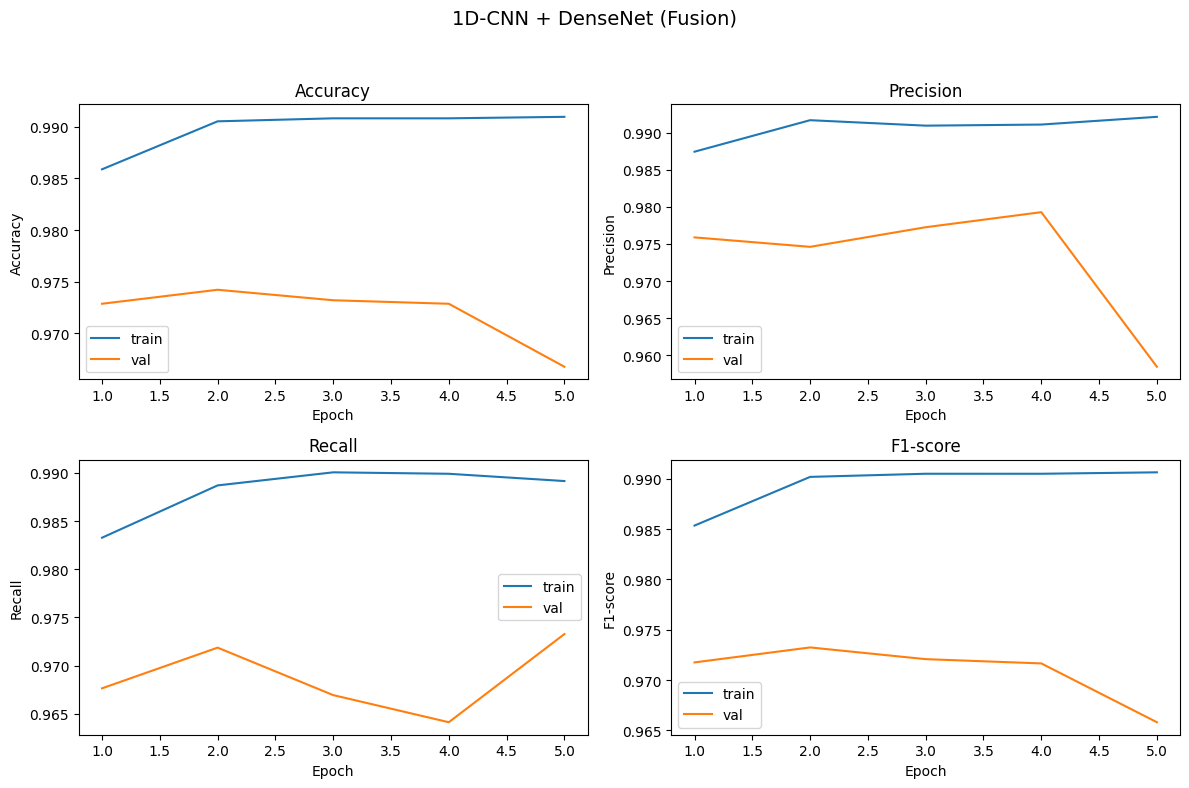

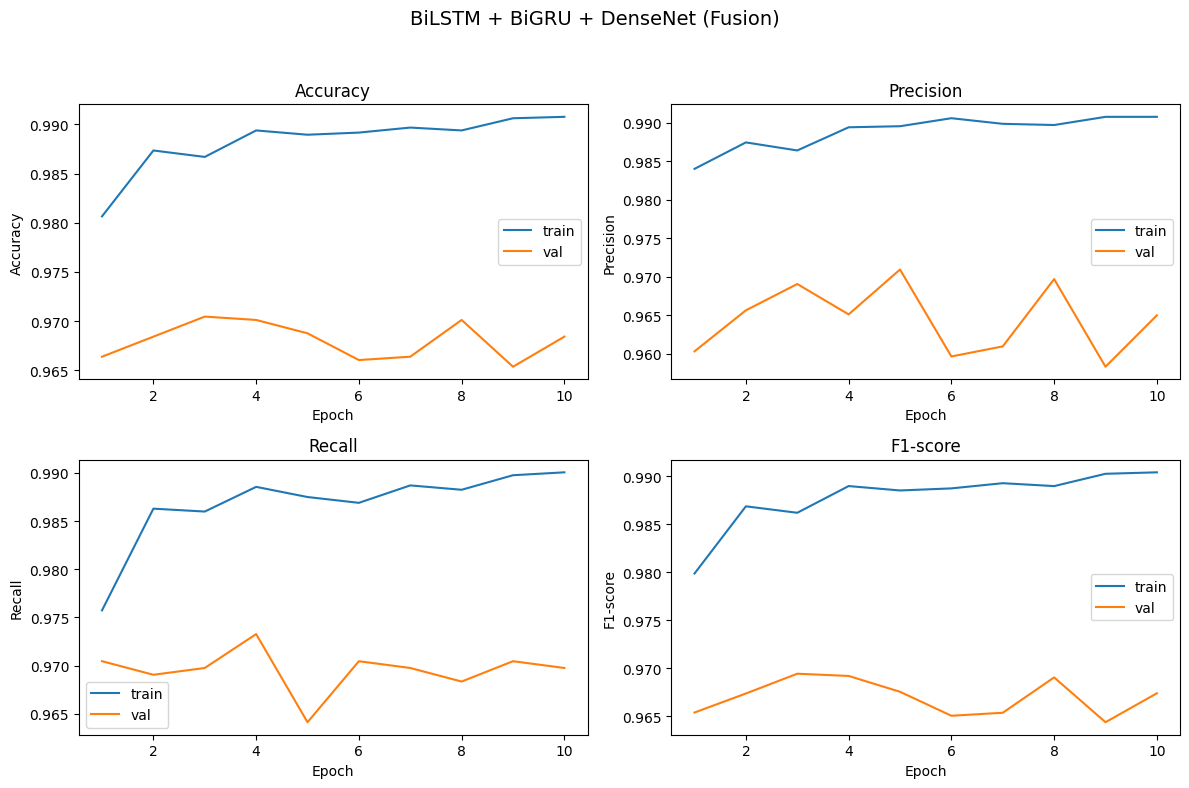

In [187]:
for name in fusion_titles:
    plot_fusion_curves(
        fusion_histories[name],
        title=fusion_titles[name],
    )

In [189]:
fusion_titles = {
    "bigru_densenet": "BiGRU + DenseNet121 (Fusion)",
    "bilstm_densenet": "BiLSTM + DenseNet121 (Fusion)",
    "gru_densenet": "GRU + DenseNet121 (Fusion)",
    "1dcnn_densenet": "1D-CNN + DenseNet121 (Fusion)",
    "bilstm_bigru_densenet": "BiLSTM-BiGRU + DenseNet121 (Fusion)",
}

import numpy as np
import matplotlib.pyplot as plt

def plot_fusion_curves(history, title="Fusion"):
    h = history.history

    # Metrics
    acc, val_acc = h["accuracy"], h["val_accuracy"]
    pre, val_pre = h["precision"], h["val_precision"]
    rec, val_rec = h["recall"], h["val_recall"]

    # F1 from precision & recall
    pre_np, rec_np = np.array(pre), np.array(rec)
    val_pre_np, val_rec_np = np.array(val_pre), np.array(val_rec)

    f1 = 2 * (pre_np * rec_np) / (pre_np + rec_np + 1e-8)
    val_f1 = 2 * (val_pre_np * val_rec_np) / (val_pre_np + val_rec_np + 1e-8)

    epochs = np.arange(1, len(acc) + 1)

    # ---- 4 subplots in ONE figure ----
    fig, axs = plt.subplots(2, 2, figsize=(12, 8))
    fig.suptitle(title, fontsize=14)

    # Accuracy
    axs[0, 0].plot(epochs, acc, label="train")
    axs[0, 0].plot(epochs, val_acc, label="val")
    axs[0, 0].set_title("Accuracy")
    axs[0, 0].set_xlabel("Epoch")
    axs[0, 0].set_ylabel("Accuracy")
    axs[0, 0].legend()

    # Precision
    axs[0, 1].plot(epochs, pre, label="train")
    axs[0, 1].plot(epochs, val_pre, label="val")
    axs[0, 1].set_title("Precision")
    axs[0, 1].set_xlabel("Epoch")
    axs[0, 1].set_ylabel("Precision")
    axs[0, 1].legend()

    # Recall
    axs[1, 0].plot(epochs, rec, label="train")
    axs[1, 0].plot(epochs, val_rec, label="val")
    axs[1, 0].set_title("Recall")
    axs[1, 0].set_xlabel("Epoch")
    axs[1, 0].set_ylabel("Recall")
    axs[1, 0].legend()

    # F1-score
    axs[1, 1].plot(epochs, f1, label="train")
    axs[1, 1].plot(epochs, val_f1, label="val")
    axs[1, 1].set_title("F1-score")
    axs[1, 1].set_xlabel("Epoch")
    axs[1, 1].set_ylabel("F1-score")
    axs[1, 1].legend()

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

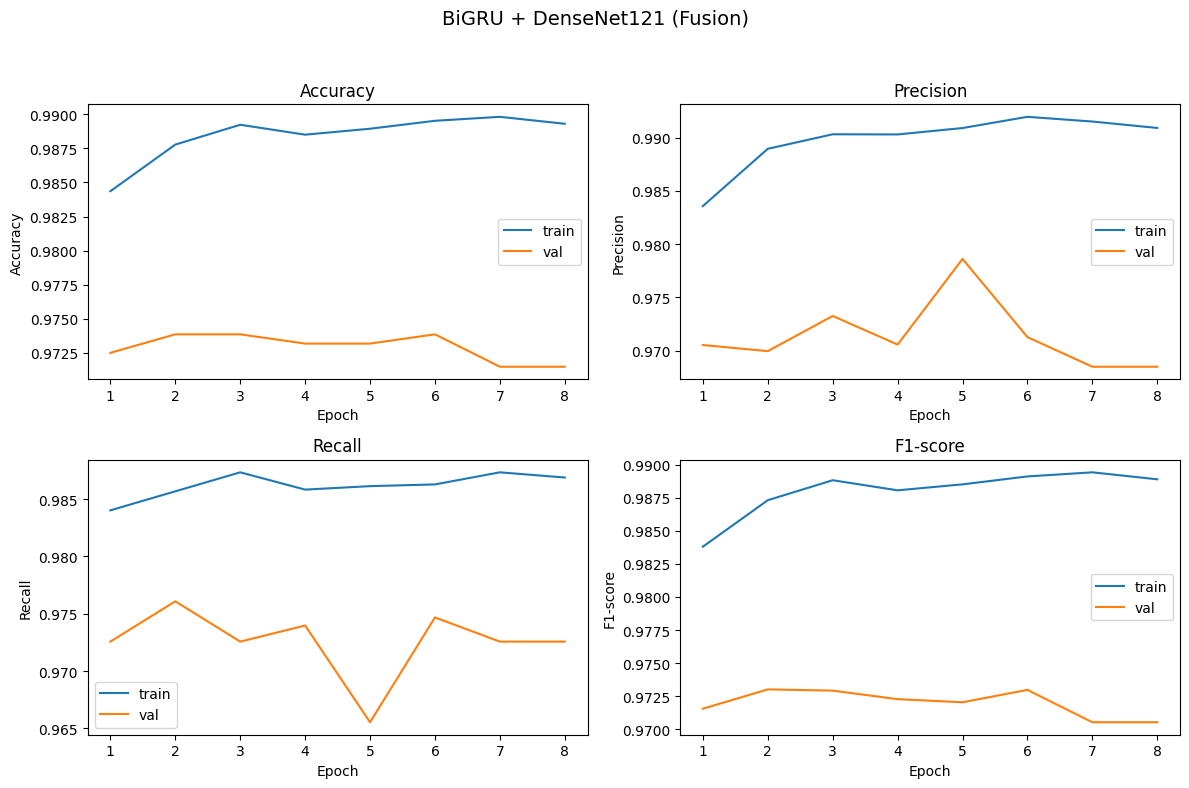

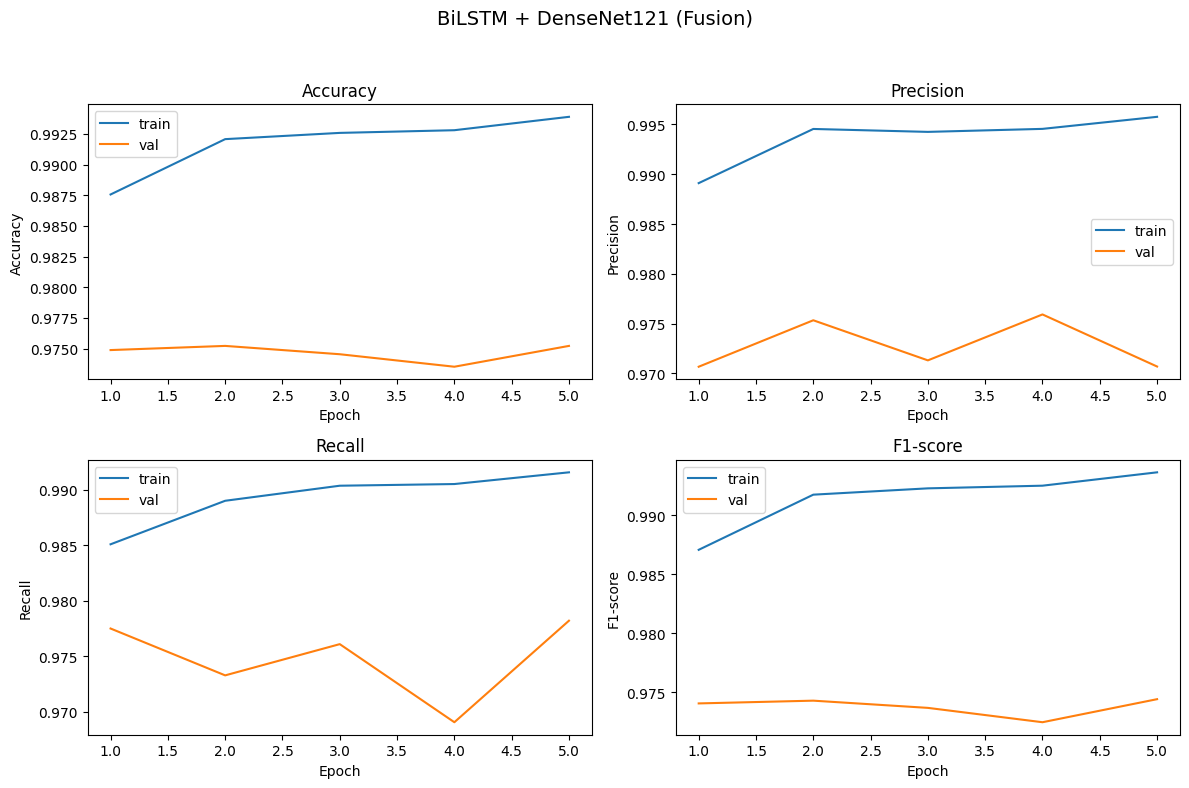

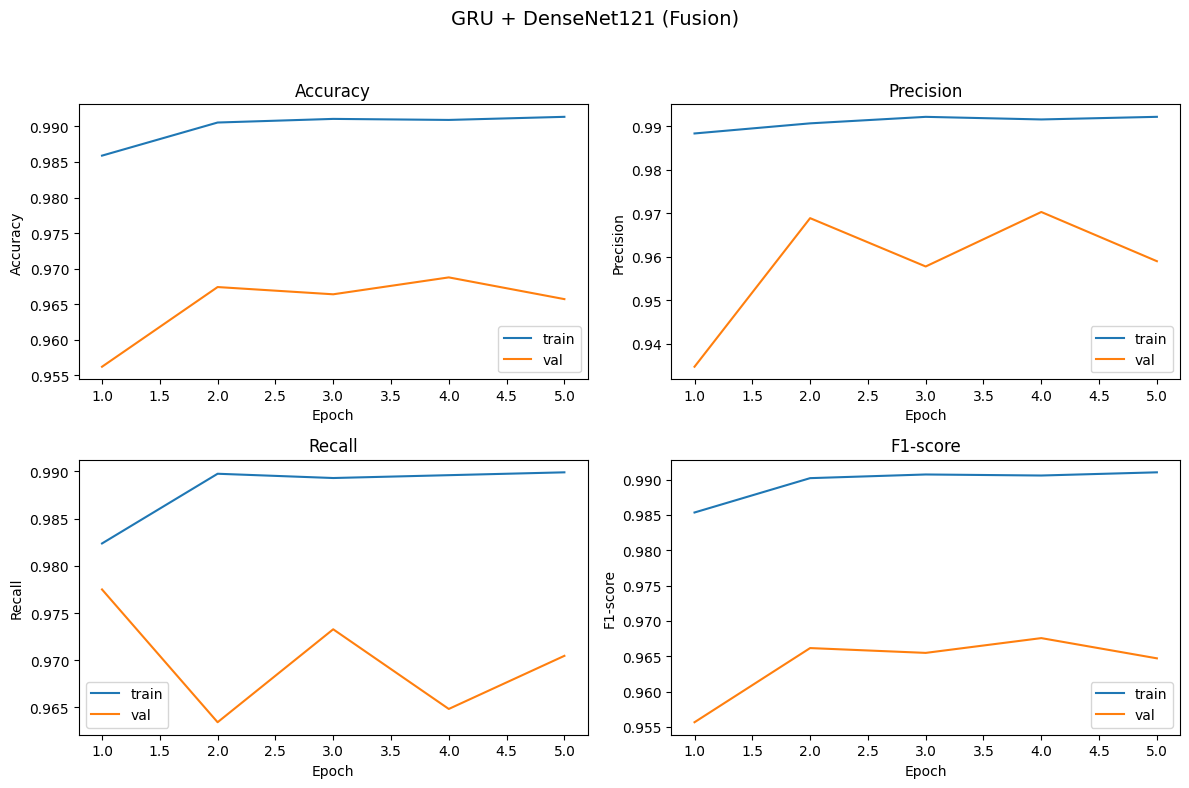

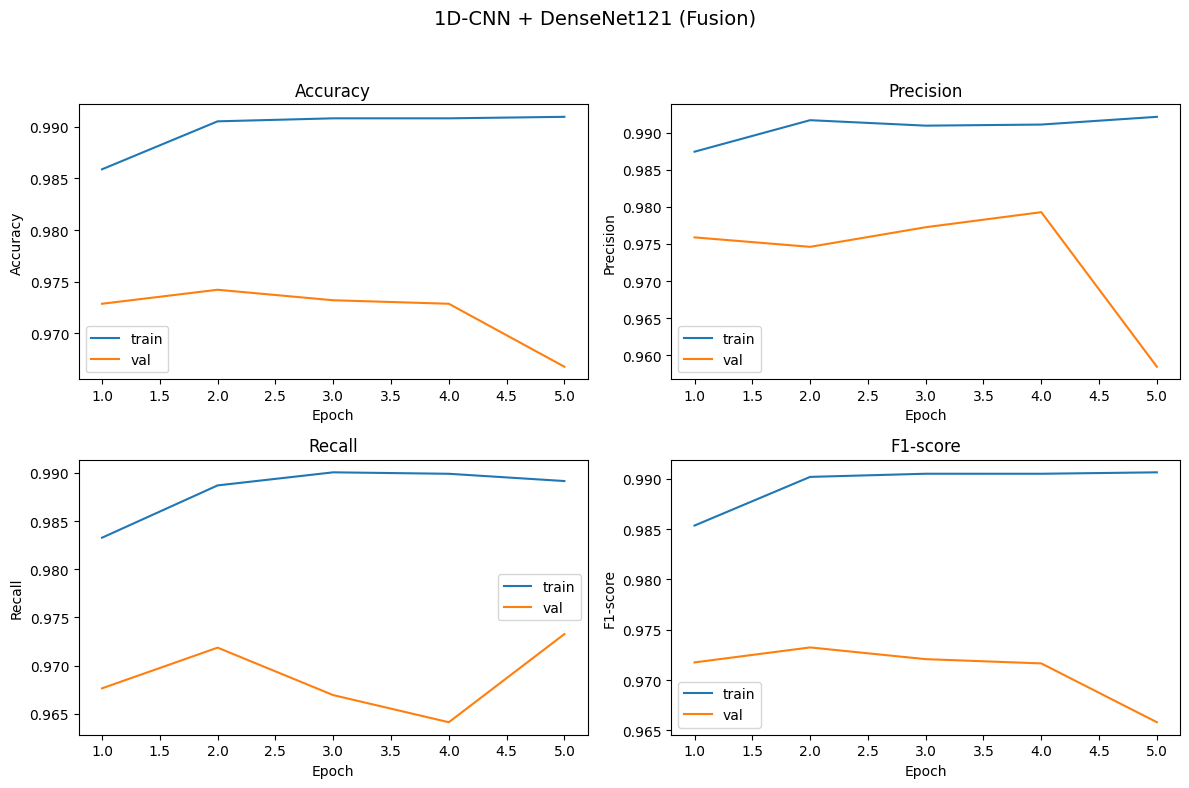

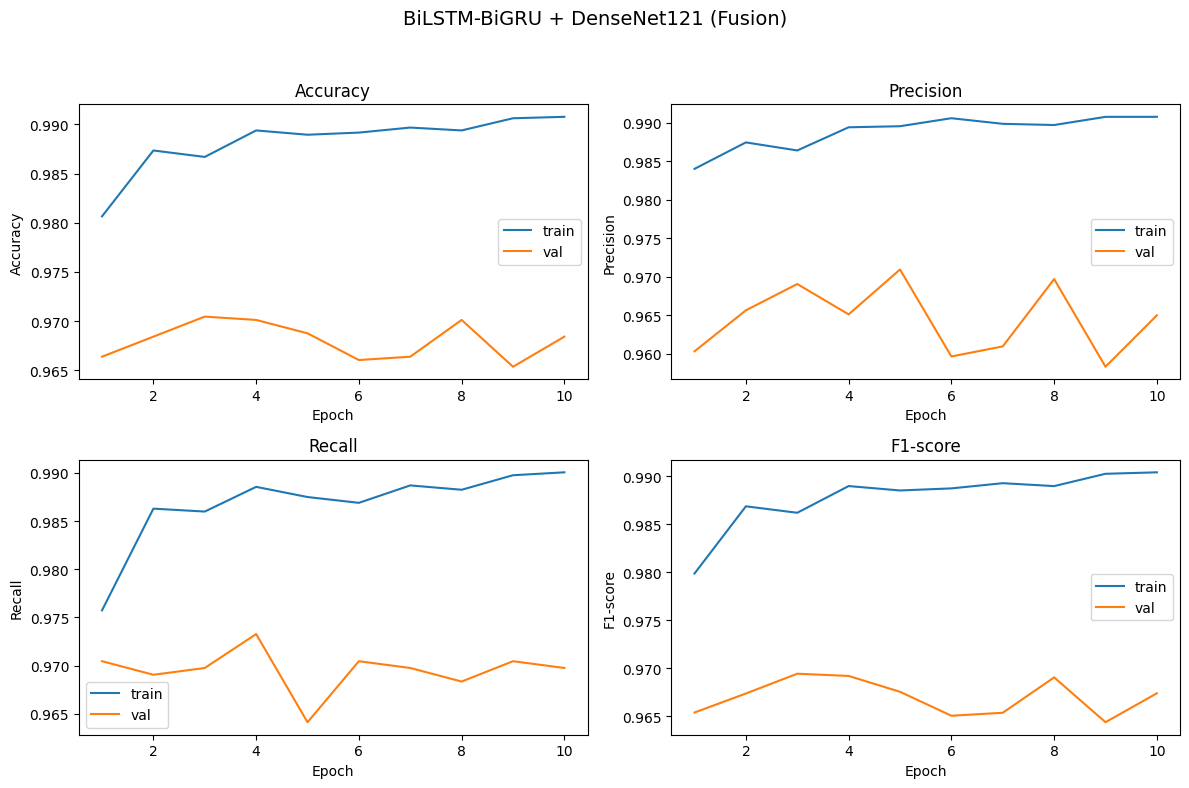

In [190]:
for name in fusion_titles:
    plot_fusion_curves(
        fusion_histories[name],
        title=fusion_titles[name],
    )

In [60]:
import gc, numpy as np, tensorflow as tf

fusion_sets = {
    "bigru_densenet":        (U["bigru_train"],        U["bigru_val"],        U["bigru_test"]),
    "bilstm_densenet":       (U["bilstm_train"],       U["bilstm_val"],       U["bilstm_test"]),
    "gru_densenet":          (U["gru_train"],          U["gru_val"],          U["gru_test"]),
    "1dcnn_densenet":        (U["1dcnn_train"],        U["1dcnn_val"],        U["1dcnn_test"]),
    "bilstm_bigru_densenet": (U["bilstm_bigru_train"], U["bilstm_bigru_val"], U["bilstm_bigru_test"]),
}


results = {}

for name, (Utr, Uva, Ute) in fusion_sets.items():
    # (optional) keep memory clean between runs
    tf.keras.backend.clear_session()
    gc.collect()

    print("\n" + "="*60)
    print(f"Training fusion: {name}")
    print("="*60)

    model = build_fusion_head(64, 128, name=f"fusion_{name}")

    hist = model.fit(
        [Utr, V_train], y_train,
        validation_data=([Uva, V_val], y_val),
        epochs=10,
        batch_size=64,
        verbose=1
    )

    test = model.evaluate([Ute, V_test], y_test, verbose=0)
    print(f"{name} Test => loss={test[0]:.4f}, acc={test[1]:.4f}, auc={test[2]:.4f}")

    model.save(f"fusion_{name}.keras")
    results[name] = {"test_loss": test[0], "test_acc": test[1], "test_auc": test[2]}


Training fusion: bigru_densenet
Epoch 1/10
215/215 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9727 - auc: 0.9958 - loss: 0.0753 - val_accuracy: 0.9701 - val_auc: 0.9948 - val_loss: 0.0903
Epoch 2/10
215/215 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9804 - auc: 0.9977 - loss: 0.0529 - val_accuracy: 0.9691 - val_auc: 0.9939 - val_loss: 0.0967
Epoch 3/10
215/215 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9828 - auc: 0.9975 - loss: 0.0509 - val_accuracy: 0.9701 - val_auc: 0.9946 - val_loss: 0.0890
Epoch 4/10
215/215 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9825 - auc: 0.9980 - loss: 0.0476 - val_accuracy: 0.9705 - val_auc: 0.9942 - val_loss: 0.0883
Epoch 5/10
215/215 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9831 - auc: 0.9980 - loss: 0.0471 - val_accuracy: 0.9718 - val_auc: 0.9944 - val_loss: 0.0919
Epoch 6/10
215/215 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9839 - auc: 0.9984 - loss: 0.0439 - val_accuracy: 0.9718 - val_auc: 0.9937 - val_loss: 0.0976
Epoch 7